In [1]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
# geopandas extends pandas to handle geospatial data and perform operations on geographic shapes.
import geopandas as gpd
# matplotlib.colors provides tools to define and manipulate colormaps for visualizations.
import matplotlib.colors as mcolors
# ListedColormap allows the creation of custom colormaps for visualizations.
from matplotlib.colors import ListedColormap
from pathlib import Path
from typing import List
from matplotlib.patches import Patch
from scipy.signal import find_peaks
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from scipy.optimize import nnls
#import matplotlib.colormaps as cm
import matplotlib.markers as mmarkers

In [2]:


def collect_files(base_dir: str, dirs: List[str], subpath: str, pattern: str, exclude: str = None) -> List[str]:
    """
    Collects files matching a pattern from specified subdirectories.

    Parameters:
        base_dir (str): Base directory containing all subdirectories.
        dirs (List[str]): List of subdirectory names.
        subpath (str): Relative path inside each subdirectory where files are located.
        pattern (str): Glob pattern to match files.
        exclude (str, optional): String pattern to exclude from results.

    Returns:
        List[str]: Sorted list of matching file paths as strings.
    """
    all_files = []
    for d in dirs:
        search_path = Path(base_dir) / d / subpath / pattern
        files = sorted(search_path.parent.glob(search_path.name))
        if exclude:
            files = [f for f in files if exclude not in f.name]
        all_files.extend([str(f) for f in files])
    return all_files

# Base directory and subdirectories
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]

# Collect files
core_processed_files = collect_files(base_dir, dirs, "core_processed", "core_faam*r1*.nc", exclude="_1hz")
dry_neph_files = collect_files(base_dir, dirs, "mo-non-core", "metoffice*neph1*.nc")
flight_sum_files = collect_files(base_dir, dirs, ".", "flight-sum*.txt")
sp2_files = collect_files(base_dir, dirs, "non-core", "man-sp2*.na")
ams_files = collect_files(base_dir, dirs, "non-core", "man-ams*.na")
lidar_files = collect_files(base_dir, dirs, "non-core", "met*.nc")
core_processed_files_1hz = collect_files(base_dir, dirs, "core_processed", "core_faam*r1*_1hz.nc")
core_processed_files_cloud = collect_files(base_dir, dirs, "core_processed", "core-cloud*r0*.nc")
#core-cloud-phy_faam_20120920_v500_r0_b737#

# Example: print or pass them into other analysis
# print(core_processed_files)


In [3]:
core_processed_files_cloud

['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b732-sep-15/core_processed/core-cloud-phy_faam_20120915_v500_r0_b732.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b733-sep-16/core_processed/core-cloud-phy_faam_20120916_v500_r0_b733.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/core_processed/core-cloud-phy_faam_20120918_v500_r0_b734.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b735-sep-19/core_processed/core-cloud-phy_faam_20120919_v500_r0_b735.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b736-sep-19/core_processed/core-cloud-phy_faam_20120919_v500_r0_b736.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/core_processed/core-cloud-phy_faam_20120920_v500_r0_b737.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b738-sep-22/core_processed/core-cloud-phy_faam_20120922_v500_r0_b738.nc',
 '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/f

In [4]:
filtered_sp2 = sp2_files[6]
filtered_ams = ams_files[2]
filtered_neph = dry_neph_files[7]
filtered_nc = core_processed_files[7]

In [5]:
filtered_nc

'/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/core_processed/core_faam_20120923_v004_r1_b739.nc'

In [6]:
ds_core_1hz = xr.open_dataset(core_processed_files_1hz[5])
ds_core = xr.open_dataset(core_processed_files[5])
ds_core_cloud = xr.open_dataset(core_processed_files_cloud[7])
      

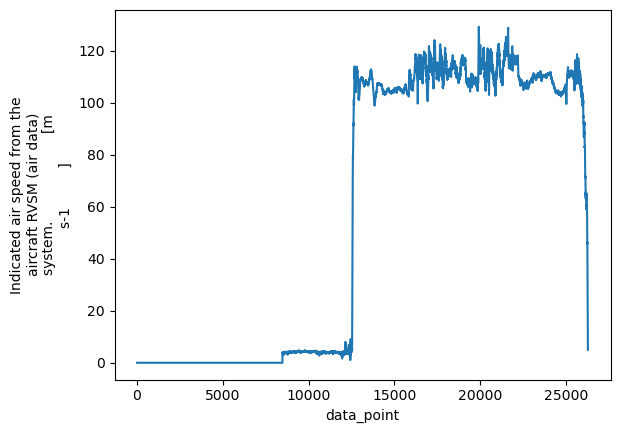

In [7]:
ds_core_1hz['IAS_RVSM'].plot()

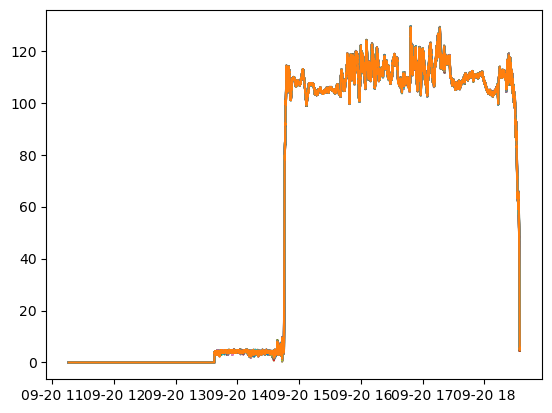

In [8]:
plt.clf()
t = ds_core['Time'].values
test = ds_core['IAS_RVSM']
plt.plot(t,test)

In [9]:
ds_core

<xarray.Dataset> Size: 286MB
Dimensions:         (data_point: 26280, sps32: 32, sps04: 4, sps01: 1,
                     sps02: 2, sps64: 64)
Dimensions without coordinates: data_point, sps32, sps04, sps01, sps02, sps64
Data variables: (12/141)
    Time            (data_point) datetime64[ns] 210kB 2012-09-20T11:16:20 ......
    IAS_RVSM        (data_point, sps32) float32 3MB 0.0 0.0 0.0 ... 4.949 4.949
    IAS_RVSM_FLAG   (data_point, sps32) float32 3MB ...
    TAS_RVSM        (data_point, sps32) float32 3MB ...
    TAS_RVSM_FLAG   (data_point, sps32) float32 3MB ...
    TAT_DI_R        (data_point, sps32) float32 3MB ...
    ...              ...
    TDEW_C_U        (data_point, sps01) float32 105kB ...
    TDEW_C_U_FLAG   (data_point, sps01) float32 105kB ...
    U_NOTURB        (data_point, sps01) float32 105kB ...
    U_NOTURB_FLAG   (data_point, sps01) float32 105kB ...
    V_NOTURB        (data_point, sps01) float32 105kB ...
    V_NOTURB_FLAG   (data_point, sps01) float32 105kB ...
Attributes: (12/22)
    conventions:         CF-1.0
    title:               Data from b737 on 20-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Tardis_Version:      v004
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20130619
    TimeInterval:        11:16:20-18:34:19
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120920_...

In [10]:
ds_core_cloud

<xarray.Dataset> Size: 19MB
Dimensions:         (Time: 27470, 2DTSPM: 27470, PCAS2CH: 30, PCAS2TSPM: 27470,
                     CDP_TSPM: 27470, CDPCH: 30)
Coordinates:
  * Time            (Time) datetime64[ns] 220kB 2012-09-23T08:24:18 ... 2012-...
  * 2DTSPM          (2DTSPM) datetime64[ns] 220kB 2012-09-23T08:24:17.500000 ...
  * PCAS2CH         (PCAS2CH) float32 120B 1.0 2.0 3.0 4.0 ... 28.0 29.0 30.0
  * PCAS2TSPM       (PCAS2TSPM) datetime64[ns] 220kB 2012-09-23T08:24:17.6992...
  * CDP_TSPM        (CDP_TSPM) datetime64[ns] 220kB 2012-09-23T08:24:17.51171...
  * CDPCH           (CDPCH) float32 120B 1.0 2.0 3.0 4.0 ... 27.0 28.0 29.0 30.0
Data variables: (12/181)
    2DC_CONC        (2DTSPM) float32 110kB ...
    2DC_CONC_FLAG   (2DTSPM) float32 110kB ...
    2DC_LWC         (2DTSPM) float32 110kB ...
    2DC_LWC_FLAG    (2DTSPM) float32 110kB ...
    2DC_IWC         (2DTSPM) float32 110kB ...
    2DC_IWC_FLAG    (2DTSPM) float32 110kB ...
    ...              ...
    CDP_D_L_NOM     (CDPCH) float32 120B ...
    CDP_D_U_NOM     (CDPCH) float32 120B ...
    CDP_D_L_CAL     (CDPCH) float32 120B ...
    CDP_D_U_CAL     (CDPCH) float32 120B ...
    CDP_D_L_ERR     (CDPCH) float32 120B ...
    CDP_D_U_ERR     (CDPCH) float32 120B ...
Attributes:
    Conventions:             CF-1.4
    title:                   Cloud Physics and Aerosol Data core-cloud-phy_fa...
    institution:             Facility for Airborne Atmospheric Measurements (...
    source:                  Aircraft measurement
    history:                 04-Dec-2012 - core-cloud-phy_faam_20120923_v500_...
    references:              www.faam.ac.uk\\nwww.badc.ac.uk
    comment:                 This data should be interpretted in association ...
    PMS2DC_Proc_Options:     Bulk quantities processed for bins 1 - 32;Comple...
    PMS2DC_MidBin_Diamater:  [37.5 62.5 87.5 112.5 137.5 162.5 187.5 212.5 23...

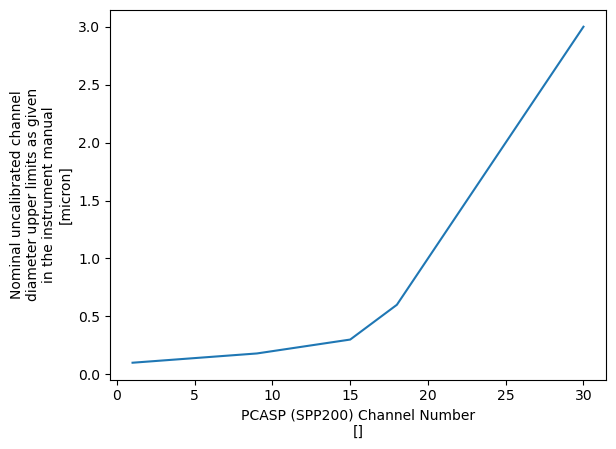

In [11]:
ds_core_cloud['PCAS2_D_U_NOM'].plot()

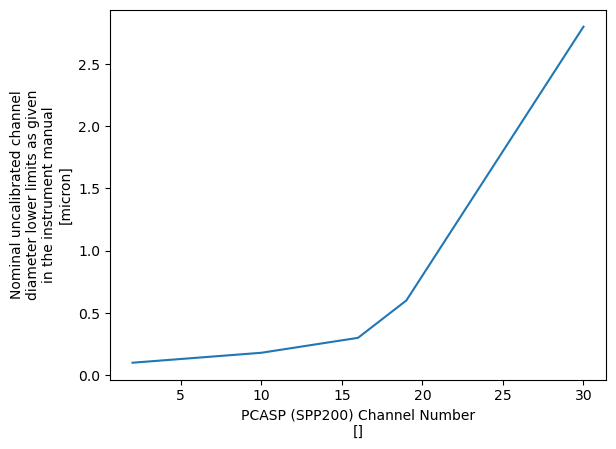

In [12]:
ds_core_cloud['PCAS2_D_L_NOM'].plot()

In [13]:
ds_core_cloud['PCAS2_D_U_NOM'].values

array([0.1 , 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.2 , 0.22,
       0.24, 0.26, 0.28, 0.3 , 0.4 , 0.5 , 0.6 , 0.8 , 1.  , 1.2 , 1.4 ,
       1.6 , 1.8 , 2.  , 2.2 , 2.4 , 2.6 , 2.8 , 3.  ], dtype=float32)

In [14]:
ds_core_cloud['PCAS2_D_U_CAL'].values

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan], dtype=float32)

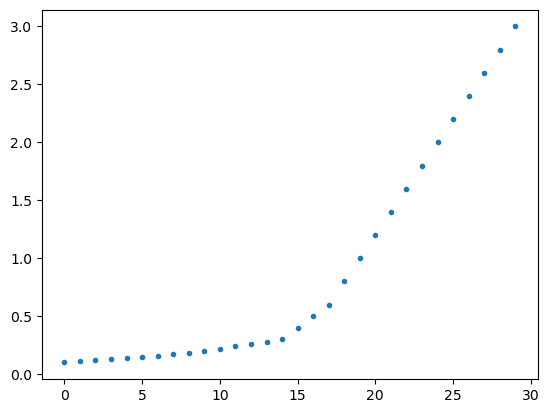

In [15]:
plt.plot(ds_core_cloud['PCAS2_D_U_NOM'],'.')

In [16]:

np.max(ds_core_cloud['PCAS2_19'])

<xarray.DataArray 'PCAS2_19' ()> Size: 4B
array(10.83595, dtype=float32)

In [17]:

def geometric_mean_diameter(D_lower_limits, D_upper_limits, concentrations):
    """
    Calculate geometric mean diameter (µm) from PCASP channel data.
    
    Parameters:
      D_lower_limits : array of lower bin limits (µm)
      D_upper_limits : array of upper bin limits (µm)
      concentrations : array of concentrations in each bin (cm⁻³)
    """

    # Mask invalid concentrations (9999, NaN, or ≤ 0)
    mask = (concentrations > 0) & (concentrations != 9999)
    D_lower = D_lower_limits[mask]
    D_upper = D_upper_limits[mask]
    conc = concentrations[mask]

    #print(D_lower)

    if len(conc) == 0:
        return np.nan  # no valid data

    # Geometric midpoints of bins
    D_mid = np.sqrt(D_lower * D_upper)
    #print(D_mid)

    # Bin width in log10 space
    dlogDp = np.log10(D_upper) - np.log10(D_lower)

    # Convert to differential distribution dN/dlogDp
    dNdlogDp = conc / dlogDp
    #print(dNdlogDp)
    #print(test)
    # Geometric mean diameter
    numerator = np.nansum(dNdlogDp * np.log(D_mid))
    #print(numerator)
    denominator = np.nansum(dNdlogDp)

    Dg = np.exp(numerator / denominator)  # in µm
    return Dg

In [18]:

def geometric_mean_diameter_v2(D_lower, D_upper, concentrations):
    """
    Compute geometric mean diameter (µm) from channel boundaries and concentrations.
    """
    # Bin midpoints in log-space
    D_mid = np.sqrt(D_lower * D_upper)

    # Ensure concentrations is numpy array and mask invalids
    concentrations = np.array(concentrations, dtype=float)
    mask = (concentrations > 0) & (concentrations != 9999)

    if not np.any(mask):
        #print('retornou')
        return np.nan  # no valid data

    conc = concentrations[mask]
    D_mid = D_mid[mask]

    # Weighted geometric mean
    log_Dg = np.nansum(conc * np.log(D_mid)) / np.nansum(conc)
    return np.exp(log_Dg)

Max valid total concentration: 7127.3843


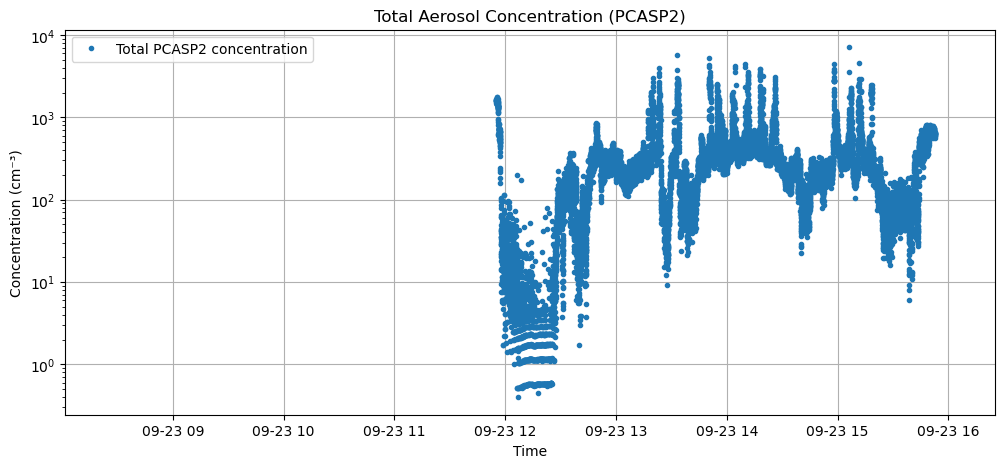

In [19]:
# Collect all PCAS2_xx variables into one DataArray (channels x time)
pcasp_channels = [f"PCAS2_{i:02d}" for i in range(1, 31)]  # PCAS2_01 ... PCAS2_30
da_pcasp = xr.concat([ds_core_cloud[v] for v in pcasp_channels], dim="PCAS2CH")

# Replace invalid values (9999) with NaN
da_pcasp = da_pcasp.where(da_pcasp <= 9999)

# Sum concentrations across channels (ignoring NaNs)
total_conc = da_pcasp.sum(dim="PCAS2CH", skipna=True)

print("Max valid total concentration:", np.nanmax(total_conc.values))

# Plot
plt.figure(figsize=(12,5))
plt.plot(total_conc['PCAS2TSPM'].values, total_conc.values,'.', label="Total PCASP2 concentration")

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Concentration (cm⁻³)")
plt.title("Total Aerosol Concentration (PCASP2)")
plt.grid(True)
plt.legend()
plt.show()

Max valid 1-min total concentration: 1920.4026


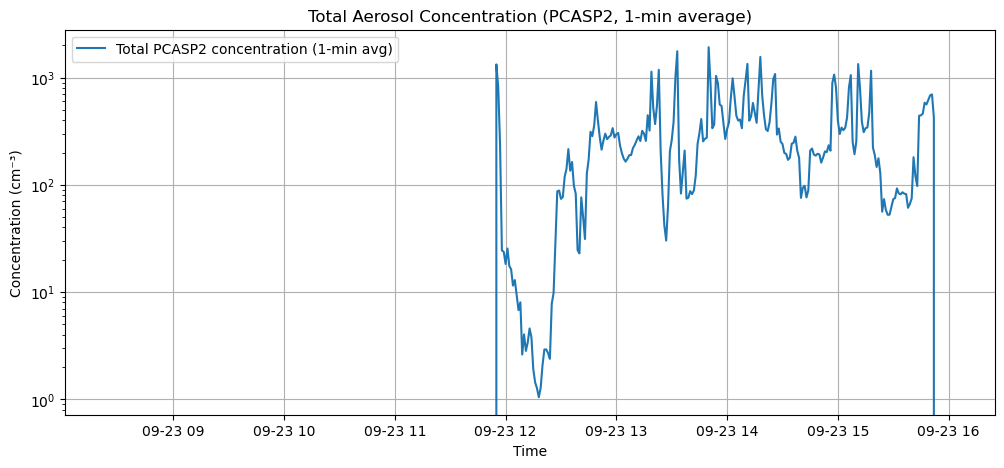

In [20]:
# Collect all PCAS2_xx variables into one DataArray (channels x time)
pcasp_channels = [f"PCAS2_{i:02d}" for i in range(1, 31)]
da_pcasp = xr.concat([ds_core_cloud[v] for v in pcasp_channels], dim="PCAS2CH")

# Replace invalid values (9999) with NaN
da_pcasp = da_pcasp.where(da_pcasp <= 9999)

# Sum concentrations across channels (ignoring NaNs)
total_conc = da_pcasp.sum(dim="PCAS2CH", skipna=True)

# Resample to 1-minute averages
total_conc_1min = total_conc.resample(PCAS2TSPM="1min").mean(skipna=True)

print("Max valid 1-min total concentration:", np.nanmax(total_conc_1min.values))

# Plot
plt.figure(figsize=(12,5))
plt.plot(total_conc_1min['PCAS2TSPM'].values, total_conc_1min.values,
         label="Total PCASP2 concentration (1-min avg)")

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Concentration (cm⁻³)")
plt.title("Total Aerosol Concentration (PCASP2, 1-min average)")
plt.grid(True)
plt.legend()
plt.show()

Detected peak times and values:
2012-09-23T11:55:00 1327.66
2012-09-23T12:01:00 25.45
2012-09-23T12:05:00 12.94
2012-09-23T12:08:00 8.01
2012-09-23T12:10:00 4.03
2012-09-23T12:13:00 4.57
2012-09-23T12:22:00 2.91
2012-09-23T12:29:00 88.49
2012-09-23T12:34:00 215.44
2012-09-23T12:36:00 163.35
2012-09-23T12:41:00 76.38
2012-09-23T12:46:00 312.76
2012-09-23T12:49:00 592.08
2012-09-23T12:54:00 299.89
2012-09-23T12:58:00 338.00
2012-09-23T13:01:00 304.29
2012-09-23T13:12:00 283.51
2012-09-23T13:14:00 318.95
2012-09-23T13:17:00 445.95
2012-09-23T13:19:00 1136.72
2012-09-23T13:23:00 1182.34
2012-09-23T13:33:00 1761.49
2012-09-23T13:37:00 208.68
2012-09-23T13:40:00 87.35
2012-09-23T13:46:00 410.94
2012-09-23T13:50:00 1920.40
2012-09-23T13:54:00 1037.37
2012-09-23T14:03:00 983.87
2012-09-23T14:07:00 406.22
2012-09-23T14:11:00 1343.92
2012-09-23T14:14:00 579.71
2012-09-23T14:18:00 1559.30
2012-09-23T14:26:00 1080.94
2012-09-23T14:28:00 335.34
2012-09-23T14:37:00 281.35
2012-09-23T14:42:00 98.08
2

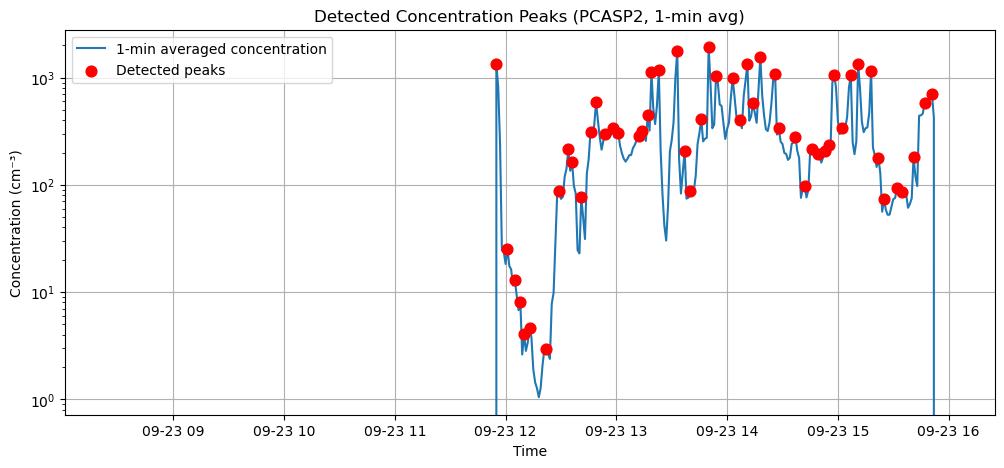

In [21]:
# --- Step 2: Find peaks ---
# Convert to numpy for peak detection
y = total_conc_1min.values
x = total_conc_1min['PCAS2TSPM'].values

# Find peaks (you can adjust "height" or "distance" to filter noise)
peaks, properties = find_peaks(y, height=0, distance=2)

# --- Step 3: Extract times of peaks ---
peak_times = x[peaks]
peak_values = y[peaks]

# Convert to list of (time, value)
peaks_list = list(zip(peak_times, peak_values))

print("Detected peak times and values:")
for t, v in peaks_list:
    print(str(t)[:19], f"{v:.2f}")

# --- Step 4: Plot for visualization ---
plt.figure(figsize=(12,5))
plt.plot(x, y, label="1-min averaged concentration")
plt.scatter(peak_times, peak_values, color="red", s=60, zorder=5, label="Detected peaks")
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Concentration (cm⁻³)")
plt.title("Detected Concentration Peaks (PCASP2, 1-min avg)")
plt.grid(True)
plt.legend()
plt.show()

In [22]:
# Filter peaks above 90 cm⁻³
aux_times = [str(t)[:19] for t, v in peaks_list if v > 90]

print("Auxiliary list of times with peaks > 90 cm⁻³:")
print(aux_times)

Auxiliary list of times with peaks > 90 cm⁻³:
['2012-09-23T11:55:00', '2012-09-23T12:34:00', '2012-09-23T12:36:00', '2012-09-23T12:46:00', '2012-09-23T12:49:00', '2012-09-23T12:54:00', '2012-09-23T12:58:00', '2012-09-23T13:01:00', '2012-09-23T13:12:00', '2012-09-23T13:14:00', '2012-09-23T13:17:00', '2012-09-23T13:19:00', '2012-09-23T13:23:00', '2012-09-23T13:33:00', '2012-09-23T13:37:00', '2012-09-23T13:46:00', '2012-09-23T13:50:00', '2012-09-23T13:54:00', '2012-09-23T14:03:00', '2012-09-23T14:07:00', '2012-09-23T14:11:00', '2012-09-23T14:14:00', '2012-09-23T14:18:00', '2012-09-23T14:26:00', '2012-09-23T14:28:00', '2012-09-23T14:37:00', '2012-09-23T14:42:00', '2012-09-23T14:46:00', '2012-09-23T14:49:00', '2012-09-23T14:53:00', '2012-09-23T14:55:00', '2012-09-23T14:58:00', '2012-09-23T15:02:00', '2012-09-23T15:07:00', '2012-09-23T15:11:00', '2012-09-23T15:18:00', '2012-09-23T15:22:00', '2012-09-23T15:32:00', '2012-09-23T15:41:00', '2012-09-23T15:47:00', '2012-09-23T15:51:00']


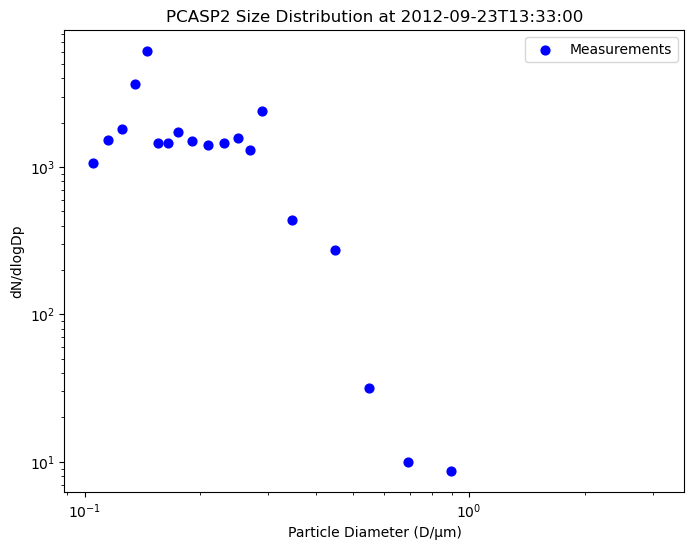

In [23]:
# Take one time from aux_times (example: first one)
time_sel = aux_times[13]

# Select nearest snapshot at that time
snapshot = da_pcasp.sel(PCAS2TSPM=time_sel, method="nearest")

# Get diameters (bin edges) and concentrations
D_edges = ds_core_cloud['PCAS2_D_L_NOM'].values  # lower bin limits [µm]
concentrations = snapshot.values  # cm⁻³

# For bin upper edges, append a max diameter (instrument range)
# Here we assume the last bin edge extends one step further
D_upper = np.append(D_edges[1:], D_edges[-1] * 1.2)  
# Approximate last bin edge (20% larger than last lower bound)

# Compute bin centers
D_mid = np.sqrt(D_edges * D_upper)

# Compute dlogDp (log10 bin widths)
dlogDp = np.log10(D_upper) - np.log10(D_edges)

# Compute dN/dlogDp
dNdlogDp = concentrations / dlogDp

# --- Plot ---
plt.figure(figsize=(8,6))
plt.scatter(D_mid, dNdlogDp, c="blue", s=40, label="Measurements")
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Particle Diameter (D/µm)")
plt.ylabel("dN/dlogDp")
plt.title(f"PCASP2 Size Distribution at {time_sel}")
#plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

In [24]:
# Example usage with snapshot at time_sel
snapshot = da_pcasp.sel(PCAS2TSPM=time_sel, method="nearest")
concentrations = snapshot.values
print(concentrations)

D_lower_limits = ds_core_cloud['PCAS2_D_L_NOM'].values
D_upper_limits = ds_core_cloud['PCAS2_D_U_NOM'].values

Dg = geometric_mean_diameter(D_lower_limits, D_upper_limits, concentrations)
print(f"Geometric mean diameter at {time_sel}: {Dg:.3f} µm")

[664.37463  43.86017  57.93113  62.48593 117.11561 182.926    40.56073
  38.49381  43.04982  68.30672  58.38053  55.07781  54.2599   41.84256
  71.68668  54.72705  26.57264   2.49555   1.25105   0.83801   0.
   0.        0.        0.        0.        0.        0.        0.
   0.        0.     ]
Geometric mean diameter at 2012-09-23T13:33:00: 0.172 µm


In [25]:
times =  da_pcasp['PCAS2TSPM'].values
len(times)

27470

In [26]:
# ---- Run over all times ----
D_lower_limits = ds_core_cloud['PCAS2_D_L_NOM'].values
D_upper_limits = ds_core_cloud['PCAS2_D_U_NOM'].values

# Sum concentrations across channels (ignoring NaNs)
#total_conc = da_pcasp.sum(dim="PCAS2CH", skipna=True)

# Resample to 1-minute averages
#total_conc_1min = total_conc.resample(PCAS2TSPM="1min").mean(skipna=True)


times =  da_pcasp['PCAS2TSPM'].values
geom_diam_list = []

for t in times:
    #snapshot = da_pcasp.sel(PCAS2TSPM=t)
    snapshot = da_pcasp.sel(PCAS2TSPM=t)
    concentrations = snapshot.values
    Dg = geometric_mean_diameter_v2(D_lower_limits, D_upper_limits, concentrations)
    geom_diam_list.append((t, Dg))

# Example: print first 10
for t, Dg in geom_diam_list[:10]:
    print(str(t)[:19], f"{Dg:.3f} µm")


2012-09-23T08:24:17 nan µm
2012-09-23T08:24:18 nan µm
2012-09-23T08:24:19 nan µm
2012-09-23T08:24:20 nan µm
2012-09-23T08:24:21 nan µm
2012-09-23T08:24:22 nan µm
2012-09-23T08:24:23 nan µm
2012-09-23T08:24:24 nan µm
2012-09-23T08:24:25 nan µm
2012-09-23T08:24:26 nan µm


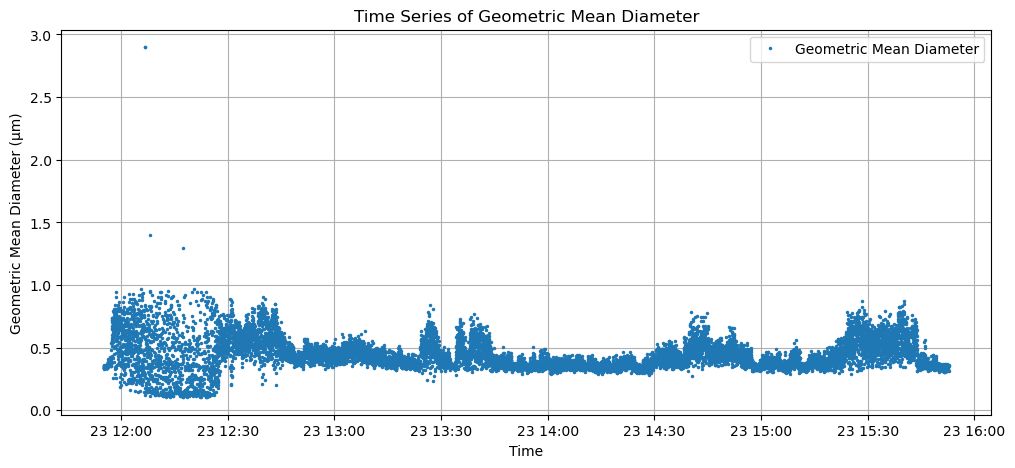

In [27]:
# Unpack times and diameters
times, Dgs = zip(*geom_diam_list)

plt.figure(figsize=(12,5))
plt.plot(times, Dgs, ".", markersize=3, label="Geometric Mean Diameter")

plt.xlabel("Time")
plt.ylabel("Geometric Mean Diameter (µm)")
plt.title("Time Series of Geometric Mean Diameter")
plt.grid(True)
plt.legend()
plt.show()

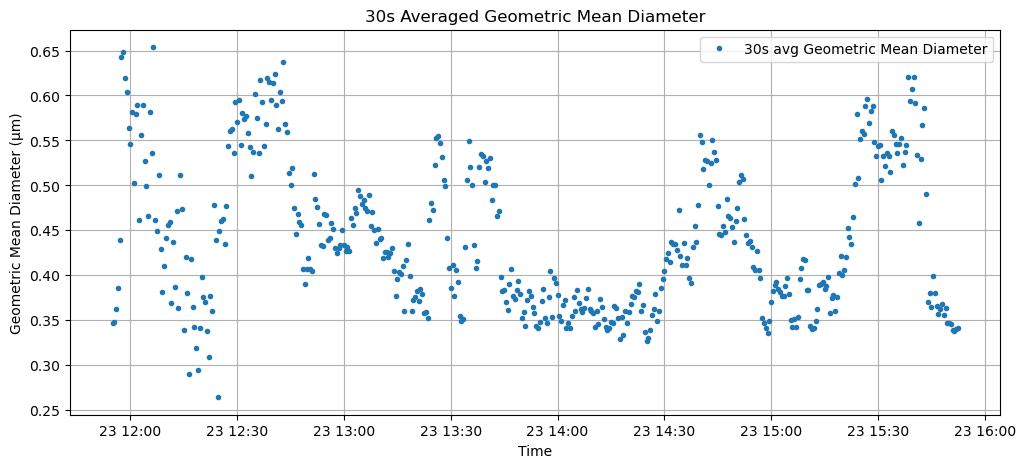

In [28]:
# Convert to pandas Series
times, Dgs = zip(*geom_diam_list)
series = pd.Series(Dgs, index=pd.to_datetime(times))

# Resample to 1-minute mean
Dgs_1min = series.resample("30s").mean()

# Plot
plt.figure(figsize=(12,5))
plt.plot(Dgs_1min.index, Dgs_1min.values, "o", markersize=3, label="30s avg Geometric Mean Diameter")

plt.xlabel("Time")
plt.ylabel("Geometric Mean Diameter (µm)")
plt.title("30s Averaged Geometric Mean Diameter")
plt.grid(True)
plt.legend()
plt.show()

In [29]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds_t = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds_t])

    dsf = dsf.assign_coords(time=dsf['neph_spm'])
    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))
    #dsf["Times"] = (("time",), datetime_values)
    #dsf["datetime"] = (("time",), datetime_values)
    #dsf = dsf.set_coords('neph_spm')

    return dsf

In [30]:
def dataset_sp2_ams_neph(file_path_sp2,file_path_ams,file_path_neph):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )
 
    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None


    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams,ds_neph

In [31]:
def Nc_file_treatment_v2(aux_ds_sp2, aux_ds_ams, aux_ds_psap):
    import numpy as np
    import xarray as xr

    variables = ["SO4", "NH4", "ORG", "NO3", "Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    # Prepare individual valid masks and apply them
    resampled_vars = {}
    resampled_uncs = {}

    for var in variables:
        valid_mask = (aux_ds_ams[var] != 9999999) & (aux_ds_ams[var] >= 0)
        filtered = aux_ds_ams[var].where(valid_mask)
        resampled_vars[var] = filtered.resample(datetime="30s").mean()

    for unc in variables_unc:
        resampled_uncs[unc] = aux_ds_ams[unc].resample(datetime="30s").mean()

    # Process BC_mass
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2["BC_mass"].where(valid_BC_mass_mask) * 1e-3  # Convert to µg/m³
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="30s").mean()

    # Sum only valid AMS components at each time
    total_mass_ams = sum(v.fillna(0) for v in resampled_vars.values())

    # Sum only available AMS uncertainties (quadrature)
    total_uncertainty_ams = np.sqrt(sum((resampled_uncs[unc].fillna(0))**2 for unc in variables_unc))

    # Total BC mass (only one component here)
    total_mass_bc = resampled_ds_sp2

    # Combine AMS + BC total mass
    total_mass = total_mass_ams + total_mass_bc

    # PSAP filtering
    resampled_psap = aux_ds_psap.resample(Time='30s').mean()
    valid_PSAP_mask = (
        (resampled_psap["CO_AERO_FLAG"] == 0) &
        (resampled_psap["CO_AERO"] >= 160) &
        (resampled_psap["GPS_ALT"] <= 3000) &
        (resampled_psap["GPS_ALT"] >= 200)
    )
    filtered_ds_psap = resampled_psap.where(valid_PSAP_mask, drop=False)
    filtered_ds_psap_aux = resampled_psap.where(valid_PSAP_mask, drop=True)

    # Match times
    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])
    total_mass_matched = total_mass.sel(time=common_times)
    total_mass_matched_uncertainty = total_uncertainty_ams.sel(time=common_times)
    #ds_psap_matched = filtered_ds_psap.sel(data_point=common_times)

    # Create auxiliary PSAP dataset with matching times
    psap_time = filtered_ds_psap_aux['data_point'].values
    mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])
    ds_psap_matched_aux = filtered_ds_psap_aux.where(mask, drop=True)

    # Optional mass breakdowns
    amonium_sulfate_nitrate = (
        resampled_vars["SO4"] +
        resampled_vars["NH4"] +
        resampled_vars["NO3"]
    )
    org = resampled_vars["ORG"]
    bc_mass = resampled_ds_sp2

    data_masses = [bc_mass, amonium_sulfate_nitrate, org]

    return ds_psap_matched_aux, total_mass_matched, total_mass_matched_uncertainty, ds_psap_matched_aux, data_masses


In [32]:
def growth_func_calc(ds_nc):
    
    # Extract the dew point and time
    T_dew_K = ds_nc['TDEW_GE']  # Dew point temperature in Kelvin
    time = ds_nc['data_point']  # Time variable
    # Extract the True air temperature and time
    T_air_K = ds_nc['TAT_DI_R']  # True air temperature in Kelvin with shape (20998, 32)
    
    # Convert 'Time' to a pandas datetime index for resampling
    # Ensure the 'Time' variable is in seconds or a similar time unit that pandas can work with
    time_index = pd.to_datetime(time.values, unit='s')
    
    T_dew_flat = T_dew_K.values.flatten()
    time_flat_dew = time_index.repeat(T_dew_K.shape[1])  # Repeat the time values for each frequency (4Hz)
    
    
    # Create a pandas DataFrame for easier resampling
    df = pd.DataFrame({'Time': time_flat_dew, 'TDEW_GE': T_dew_flat})
    
    # Resample the data by 1 minute and calculate the mean for each interval
    df_resampled = df.resample('30s', on='Time').mean()
    
    # Convert the resampled dew point temperature back to an xarray
    T_dew_resampled = xr.DataArray(df_resampled['TDEW_GE'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})
    
    # Step 2: Create a pandas DataFrame for resampling
    # Flatten the TAT_DI_R array to make it 1D for DataFrame construction
    T_air_flat = T_air_K.values.flatten()
    time_flat_air = time_index.repeat(T_air_K.shape[1])  # Repeat the time values for each frequency (32Hz)
    
    # Create a DataFrame with the flattened arrays
    df = pd.DataFrame({'Time': time_flat_air, 'TAT_DI_R': T_air_flat})
    
    # Step 3: Resample the data by 1 minute and compute the mean for each time interval
    df_resampled = df.resample('30s', on='Time').mean()
    
    # Step 4: Convert back to xarray
    T_air_resampled = xr.DataArray(df_resampled['TAT_DI_R'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})

    # Convert from Kelvin to Celsius
    T_dew_resampled_C = T_dew_resampled - 273.15
    
    # Convert from Kelvin to Celsius
    T_air_resampled_C = T_air_resampled - 273.15
    
    # Convert to Celsius
    T_dew_C = T_dew_resampled_C
    T_air_C = T_air_resampled_C
    
    # Calculate relative humidity using the Magnus formula
    RH = 100 * (np.exp((17.625 * T_dew_C) / (243.04 + T_dew_C)) /
                np.exp((17.625 * T_air_C) / (243.04 + T_air_C)))

    alpha = 0.15
    fh = (1-(RH)/100)**(-alpha)


    return fh

In [33]:
def calculate_scatering_eff_v2(aux_ds_sp2,aux_ds_ams,aux_ds_neph):

    # List of variables to check for invalid values
    variables = ["SO4", "NH4", "ORG", "NO3","Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    #(aux_ds_sp2["BC_mass"] != 9999999) & (aux_ds_sp2["BC_mass"] >= 0)
    # Build a combined valid mask using xarray operations
    valid_mask = (aux_ds_ams[variables[0]] != 9999999) & (aux_ds_ams[variables[0]] >= 0)
    for var in variables[1:]:
        valid_mask = valid_mask & (aux_ds_ams[var] != 9999999)  & (aux_ds_ams[var]  >= 0)
    
    # Apply the combined mask to the whole dataset
    filtered_ds = aux_ds_ams.where(valid_mask, drop=True)

    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass"] = filtered_ds_BC_mass["BC_mass"] * 1e-3

    # Resample to 1-minute means
    resampled_ams = filtered_ds.resample(datetime="30s").mean()
    resampled_neph = aux_ds_neph.resample(datetime='30s').mean()
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="30s").mean()

    #print(resampled_ds['time'].shape)
    #print(resampled_ds_sp2['BC_mass'].shape)

    # Calculate total mass across selected components
    total_mass_ams = sum(resampled_ams[var] for var in variables)
    #print(total_mass_ams)
    total_mass_bc = sum(resampled_ds_sp2[var] for var in components)
    #print(total_mass)
    total_mass = total_mass_ams + total_mass_bc

    # Compute total uncertainty (quadrature sum)
    total_uncertainty_ams = np.sqrt(sum((resampled_ams[unc] ** 2 for unc in variables_unc)))
    total_uncertainty = total_uncertainty_ams  # Assuming BC_mass has no uncertainty provided

    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])

    
    total_mass_matched = total_mass.sel(time=common_times)
    ds_neph_matched = resampled_neph.sel(time=common_times)
    total_mass_matched_uncertanty = total_uncertainty.sel(time=common_times)

    
    return ds_neph_matched,total_mass_matched,total_mass_matched_uncertanty

In [34]:
ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(filtered_sp2,filtered_ams,filtered_neph)
ds_psap = xr.open_dataset(filtered_nc)

In [35]:
ds_psap_matched,tm_psap_match,tm_psap_match_unc,test,data_masses=Nc_file_treatment_v2(ds_sp2,ds_ams,ds_psap)

In [36]:

BC_mass_match = data_masses[0]
amonium_sulfate_nitrate_mass_match = data_masses[1]
ORG_mass_match = data_masses[2]

In [37]:
time_masses_BC = BC_mass_match['time'].values
time_masses_INO = amonium_sulfate_nitrate_mass_match['time'].values
time_masses_ORG = ORG_mass_match['time'].values


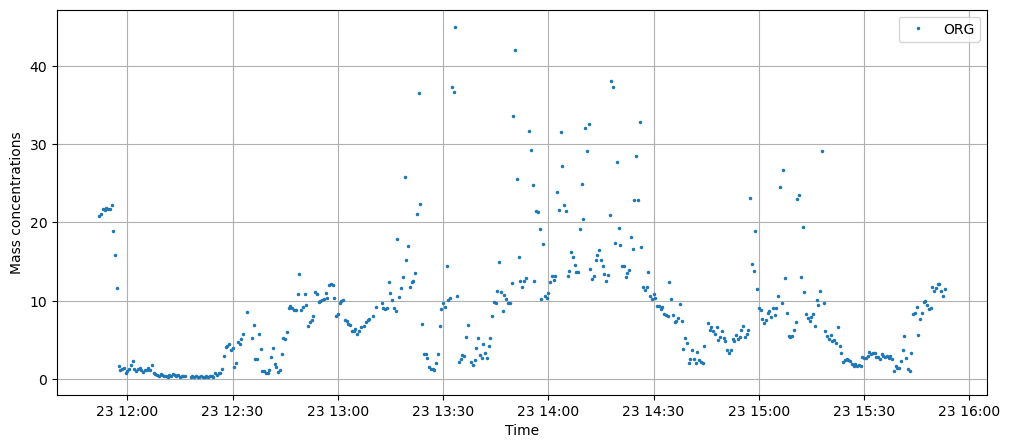

In [38]:

# Plot
plt.figure(figsize=(12,5))
#plt.plot(time_masses_BC, BC_mass_match.values, ".", markersize=3, label="BC")
#plt.plot(time_masses_INO, amonium_sulfate_nitrate_mass_match.values, ".", markersize=3, label="INO")
plt.plot(time_masses_ORG, ORG_mass_match.values, ".", markersize=3, label="ORG")

plt.xlabel("Time")
plt.ylabel("Mass concentrations")
#plt.title("1-Minute Averaged Geometric Mean Diameter")
plt.grid(True)
plt.legend()
plt.show()

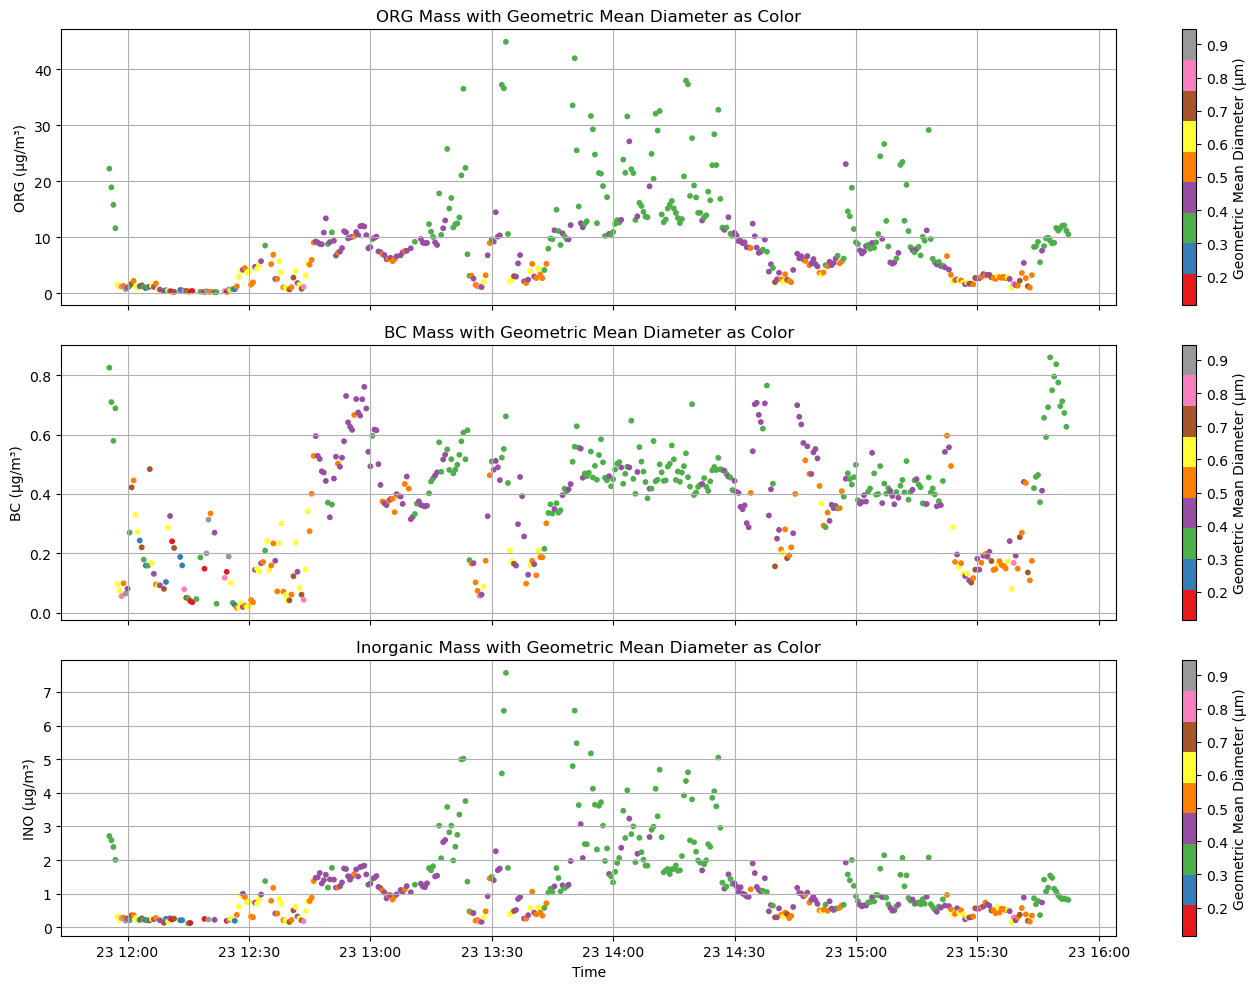

In [39]:
# Align Dg values with times
Dg_aligned_org = series.reindex(pd.to_datetime(time_masses_ORG), method="nearest")
Dg_aligned_bc  = series.reindex(pd.to_datetime(time_masses_BC), method="nearest")
Dg_aligned_ino = series.reindex(pd.to_datetime(time_masses_INO), method="nearest")

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# ORG
sc1 = axes[0].scatter(time_masses_ORG, ORG_mass_match.values, 
                      c=Dg_aligned_org.values, cmap="Set1", s=10)
axes[0].set_ylabel("ORG (µg/m³)")
axes[0].set_title("ORG Mass with Geometric Mean Diameter as Color")
axes[0].grid(True)
cbar1 = fig.colorbar(sc1, ax=axes[0], label="Geometric Mean Diameter (µm)")

# BC
sc2 = axes[1].scatter(time_masses_BC, BC_mass_match.values, 
                      c=Dg_aligned_bc.values, cmap="Set1", s=10)
axes[1].set_ylabel("BC (µg/m³)")
axes[1].set_title("BC Mass with Geometric Mean Diameter as Color")
axes[1].grid(True)
cbar2 = fig.colorbar(sc2, ax=axes[1], label="Geometric Mean Diameter (µm)")

# INO
sc3 = axes[2].scatter(time_masses_INO, amonium_sulfate_nitrate_mass_match.values, 
                      c=Dg_aligned_ino.values, cmap="Set1", s=10)
axes[2].set_ylabel("INO (µg/m³)")
axes[2].set_title("Inorganic Mass with Geometric Mean Diameter as Color")
axes[2].set_xlabel("Time")
axes[2].grid(True)
cbar3 = fig.colorbar(sc3, ax=axes[2], label="Geometric Mean Diameter (µm)")

plt.tight_layout()
plt.show()

In [88]:
results_sct = []

#Calculate Scattering efficiency 
ds_neph_matched_un,tm_neph_match,tm_neph_match_unc=calculate_scatering_eff_v2(ds_sp2,ds_ams,ds_neph)

#Extract concentration data
#area_time,data_mass_concentration = Area_plot(ds_sp2,ds_ams,ds_psap)

#Filter absortion data
#valid_neph_mask = ~np.isnan(ds_neph_matched["TSC_BLUU"])
#filtered_ds_neph = ds_neph_matched.where(valid_PSAP_mask, drop=TRUE)
GF = growth_func_calc(ds_psap_matched)



#Filter absortion data
#valid_PSAP_mask = ds_psap_matched["PSAP_LIN_FLAG"] == 0
#filtered_ds_psap = ds_psap_matched.where(valid_PSAP_mask, drop=False)
#filtered_ds_psap_aux = ds_psap_matched.where(valid_PSAP_mask, drop=False)
# Ensure both arrays are 1D and aligned
#psap_values = filtered_ds_psap["PSAP_LIN"]
#tm_values_psap_match = tm_psap_match.values

#Filter CO and Hight data
ds_psap_matched_time = test["data_point"].values  # Reference timestamps
ds_neph_matched_time = ds_neph_matched_un["time"].values
common_times = np.intersect1d(ds_psap_matched_time, ds_neph_matched_time)

#CO
CO_conc_matched = test['CO_AERO'].values.squeeze()
#ds_psap_matched = test.sel(data_point=common_times)
# Stack the values
#data_masses = [bc_mass, amonium_sulfate, org, amonium_nitrate]
ds_neph_matched = ds_neph_matched_un.sel(time=common_times)
tm_neph_match = tm_neph_match.sel(time=common_times)
BC_mass_match = data_masses[0].sel(time=common_times)
amonium_sulfate_nitrate_mass_match = data_masses[1].sel(time=common_times)
ORG_mass_match = data_masses[2].sel(time=common_times)
#amonium_nitrate_mass_match = data_masses[3].sel(time=common_times)
#CHL_mass_match = data_masses[5].sel(time=common_times)
#mask = ds_psap_matched_un["PSAP_LIN"].notnull()
#ds_neph_matched = ds_neph_matched_un.where(mask, drop=True)
AUX = (tm_neph_match*1e-6)* GF
#BC_mass_match = (BC_mass_match*1e-6)* GF
#amonium_sulfate_nitrate_mass_match = (amonium_sulfate_nitrate_mass_match*1e-6)* GF
#ORG_mass_match= (ORG_mass_match*1e-6)* GF
# Ensure both arrays are 1D and aligned
#neph_values = ds_neph_matched["TSC_BLUU"].values.squeeze()
#datetimes = ds_neph_matched["Times"]#.values.squeeze()
#tm_values_neph_match = tm_neph_match.squeeze()

# Perform element-wise division, ignoring NaNs
result_sct = np.divide(ds_neph_matched["TSC_BLUU"].values.squeeze(), tm_neph_match*1e-6)
result_sct_growth = np.divide(ds_neph_matched["TSC_BLUU"].values.squeeze(), AUX)


# Compute uncertainty in the scattering efficiency (only considering uncertainty in total_mass)
rel_uncertainty_mass_sct = (tm_neph_match_unc * 1e-6) / tm_neph_match
sct_coeff_uncertainty = np.abs(result_sct * rel_uncertainty_mass_sct)
sct_coeff_uncertainty_growth_correction = np.abs(result_sct_growth * rel_uncertainty_mass_sct)

# Drop NaN values from the result if needed
Mass_scattering_eff = result_sct.where(~np.isnan(result_sct), drop=False)
sct_coeff_uncertainty = sct_coeff_uncertainty.where(~np.isnan(sct_coeff_uncertainty), drop=False)

# Drop NaN values from the result if needed
Mass_scattering_eff_growth_correction = result_sct_growth.where(~np.isnan(result_sct_growth), drop=False)
sct_coeff_uncertainty_growth_correction = sct_coeff_uncertainty_growth_correction.where(~np.isnan(sct_coeff_uncertainty_growth_correction), drop=False)

# Compute the mean, handling cases where the list might be empty
mean_mass_scattering_eff_g = np.nanmean(Mass_scattering_eff) 
std_mass_scattering_eff_g = np.nanstd(Mass_scattering_eff) 
mean_std_sct = std_mass_scattering_eff_g/np.sqrt(len(Mass_scattering_eff))
mean_sct_eff_growth_correction = np.nanmean(Mass_scattering_eff_growth_correction) 


# Extract the flight number (b###) from the file path
match = re.search(r'b\d{3}', filtered_nc)  # Looks for 'b' followed by 3 digits
flight_number = match.group(0) if match else "Unknown"
# Extract the date in yyyymmdd format
date_match = re.search(r'(\d{8})', filtered_nc)
if date_match:
    date_str = date_match.group(1)
    flight_date = datetime.strptime(date_str, "%Y%m%d").strftime("%Y-%m-%d")
else:
    flight_date = "Unknown"


# Align Dg values with matched times
Dg_aligned_matched = series.reindex(pd.to_datetime(common_times), method="nearest")

# Store results in a list
results_sct.append({
    'BC': BC_mass_match.values,
    'INO': amonium_sulfate_nitrate_mass_match.values,
    'ORG': ORG_mass_match.values,
    'Mass scattering eff (growth correction)': Mass_scattering_eff_growth_correction.values,
    'DG_aligned': Dg_aligned_matched,
    'CO': CO_conc_matched,
    'flight': flight_number
})

In [89]:
CO_conc_matched

array([ 615.5367 ,  454.88077,  421.78223,  196.2065 ,  188.06941,
        164.76448,  195.57425,  202.53539,  204.45743,  206.468  ,
        203.52803,  205.65872,  215.37016,  185.80595,  198.40675,
        196.73761,  188.37924,  169.7277 ,  208.68724,  208.52289,
        173.78677,  179.45808,  178.36427,  180.6657 ,  179.05977,
        183.30855,  194.86612,  183.26427,  170.90372,  166.12384,
        192.95044,  213.48604,  248.3549 ,  263.26974,  239.04175,
        229.17227,  233.31354,  252.98297,  272.34262,  278.93073,
        351.6273 ,  483.52826,  510.399  ,  483.02872,  489.83804,
        510.33582,  224.17747,  210.69785,  214.29533,  216.81804,
        233.7498 ,  245.49078,  247.46971,  247.1852 ,  246.36961,
        234.72346,  225.48622,  241.67827,  240.49596,  241.77309,
        246.85014,  263.00418,  258.51523,  258.55948,  254.44986,
        250.1631 ,  238.27046,  248.24738,  242.70882,  245.14932,
        246.52763,  250.28955,  265.62802,  296.2228 ,  311.71

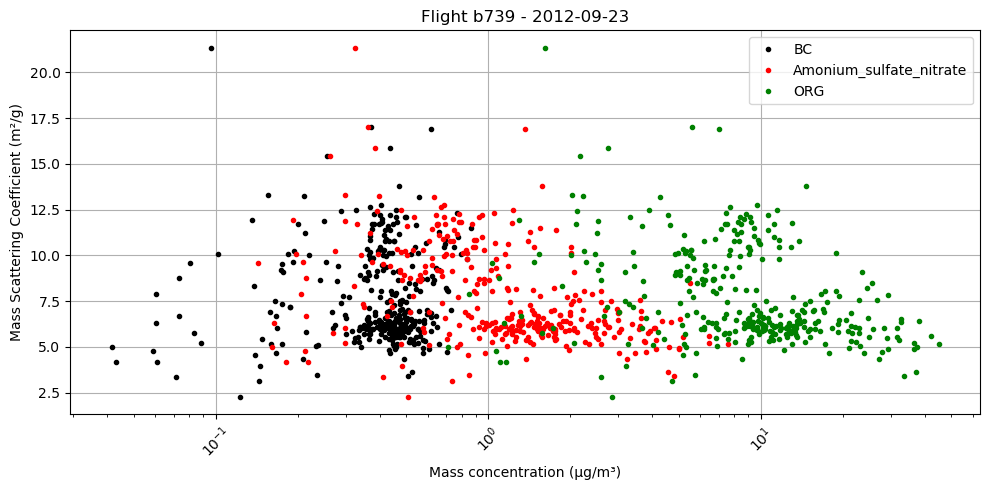

In [70]:
# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(10, 5))

# Define data and corresponding style
species_data = {
    "BC":  (BC_mass_match.values, "black"),
    "Amonium_sulfate_nitrate": (amonium_sulfate_nitrate_mass_match.values, "red"),
    "ORG": (ORG_mass_match.values, "green"),
}

# Plot all species in a loop
for label, (xdata, color) in species_data.items():
    sc = ax1.plot(xdata, Mass_scattering_eff_growth_correction.values,
             marker='.', linewidth=0, color=color, label=label)


ax1.set_xscale('log')
# Set labels and formatting
ax1.set_xlabel("Mass concentration (µg/m³)")
ax1.set_ylabel(r'Mass Scattering Coefficient (m²/g)')
ax1.set_title(f"Flight {flight_number} - {flight_date}")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)
ax1.legend(loc="best")

plt.tight_layout()
plt.show()

In [71]:
# Combine all flight data into a single dataframe
combined_data = []

for entry in results_sct:
    try:
        df = pd.DataFrame({
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
            'ME': entry['Mass scattering eff (growth correction)'],
            'Flight': entry['flight']
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data, ignore_index=True)

# Drop rows with NaNs
df_all = df_all.dropna(subset=['BC', 'INO', 'ORG', 'ME'])

# Define predictors and target
X = df_all[['BC', 'INO', 'ORG']]
y = df_all['ME']

# Fit NNLS
coef, residual_norm = nnls(X.values, y.values)

# Predicted values and R²
y_pred = X @ coef
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r_squared = 1 - ss_res / ss_tot

# Display results
print("\n✅ Combined NNLS MLR across all flights:")
for param, c in zip(X.columns, coef):
    print(f"  {param}: {c:.4f}")
print(f"  R²: {r_squared:.4f}")
print(f"  Residual norm: {residual_norm:.4f}")
print(f"  N: {len(y)}")



✅ Combined NNLS MLR across all flights:
  BC: 16.4148
  INO: 0.0000
  ORG: 0.0000
  R²: -0.8966
  Residual norm: 66.2465
  N: 339


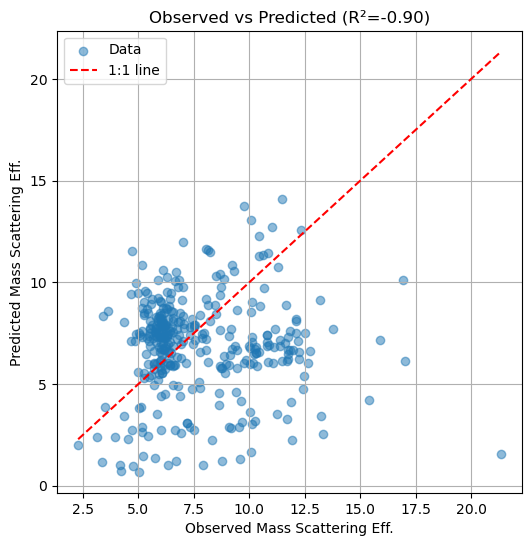

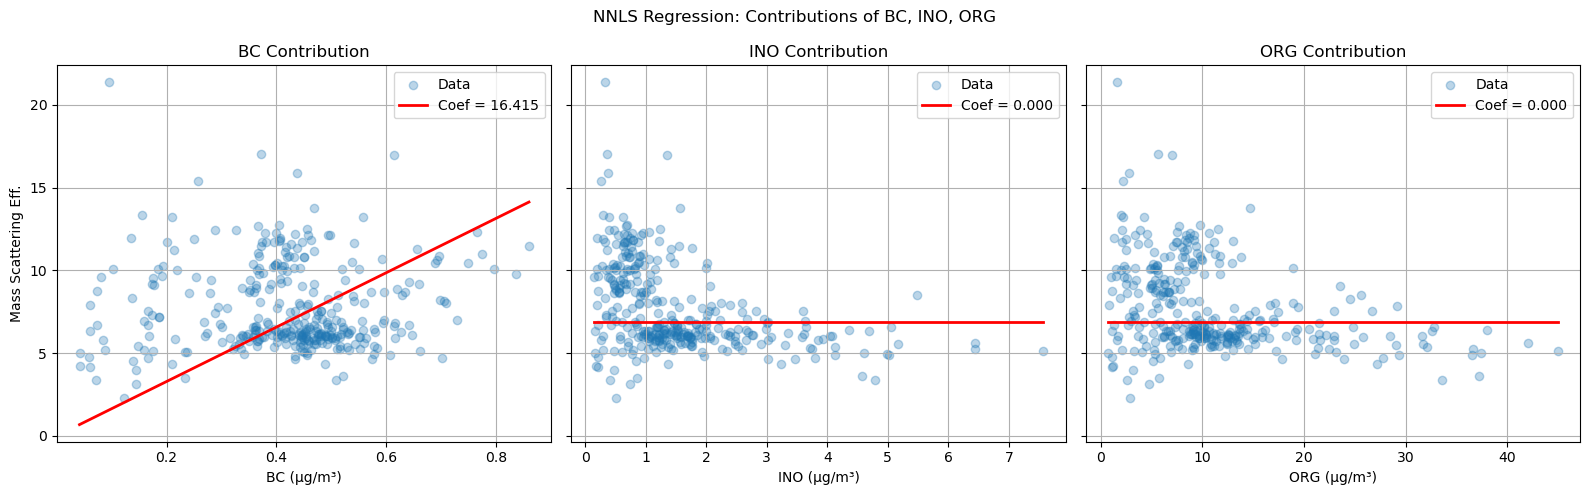

In [72]:
# --- Observed vs Predicted ME ---
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.5, label="Data")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label="1:1 line")
plt.xlabel("Observed Mass Scattering Eff.")
plt.ylabel("Predicted Mass Scattering Eff.")
plt.title(f"Observed vs Predicted (R²={r_squared:.2f})")
plt.legend()
plt.grid(True)
plt.show()

# --- Contribution plots ---
fig, axes = plt.subplots(1, 3, figsize=(16,5), sharey=True)

for ax, var, c in zip(axes, X.columns, coef):
    ax.scatter(X[var], y, alpha=0.3, label="Data")
    
    # Fit line: contribution from this predictor + mean contribution from others
    x_range = np.linspace(X[var].min(), X[var].max(), 100)
    contribution = c * x_range
    
    # To make comparison fair, add average contributions of other predictors
    other_contrib = sum(coef[j] * X.iloc[:, j].mean() 
                        for j in range(len(coef)) if X.columns[j] != var)
    y_line = contribution + other_contrib
    
    ax.plot(x_range, y_line, 'r', linewidth=2, label=f"Coef = {c:.3f}")
    ax.set_xlabel(f"{var} (µg/m³)")
    ax.set_title(f"{var} Contribution")
    ax.grid(True)
    ax.legend()

axes[0].set_ylabel("Mass Scattering Eff.")
plt.suptitle("NNLS Regression: Contributions of BC, INO, ORG")
plt.tight_layout()
plt.show()


✅ Combined NNLS MLR across all flights with DG coloring:
  BC: 16.4148
  INO: 0.0000
  ORG: 0.0000
  R²: -0.8966
  Residual norm: 66.2465
  N: 339


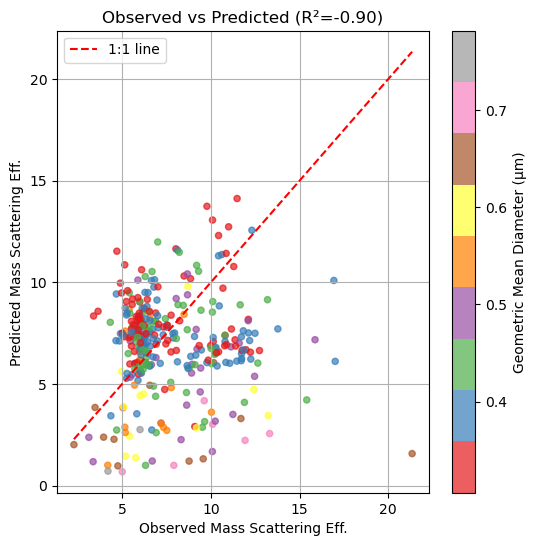

In [73]:
# Combine all flight data into a single dataframe
combined_data = []
for entry in results_sct:
    try:
        df = pd.DataFrame({
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
            'ME': entry['Mass scattering eff (growth correction)'],
            'DG': entry['DG_aligned'],
            'Flight': entry['flight']
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)

# Drop rows with NaNs
df_all = df_all.dropna(subset=['BC', 'INO', 'ORG', 'ME', 'DG'])

# Define predictors and target
X = df_all[['BC', 'INO', 'ORG']]
y = df_all['ME']
DG = df_all['DG']

# Fit NNLS
coef, residual_norm = nnls(X.values, y.values)
y_pred = X @ coef

# R²
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r_squared = 1 - ss_res / ss_tot

print("\n✅ Combined NNLS MLR across all flights with DG coloring:")
for param, c in zip(X.columns, coef):
    print(f"  {param}: {c:.4f}")
print(f"  R²: {r_squared:.4f}")
print(f"  Residual norm: {residual_norm:.4f}")
print(f"  N: {len(y)}")

# --- Observed vs Predicted with DG colorbar ---
plt.figure(figsize=(6,6))
sc = plt.scatter(y, y_pred, c=DG, cmap="Set1", alpha=0.7, s=20)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label="1:1 line")
plt.xlabel("Observed Mass Scattering Eff.")
plt.ylabel("Predicted Mass Scattering Eff.")
plt.title(f"Observed vs Predicted (R²={r_squared:.2f})")
plt.colorbar(sc, label="Geometric Mean Diameter (µm)")
plt.legend()
plt.grid(True)
plt.show()


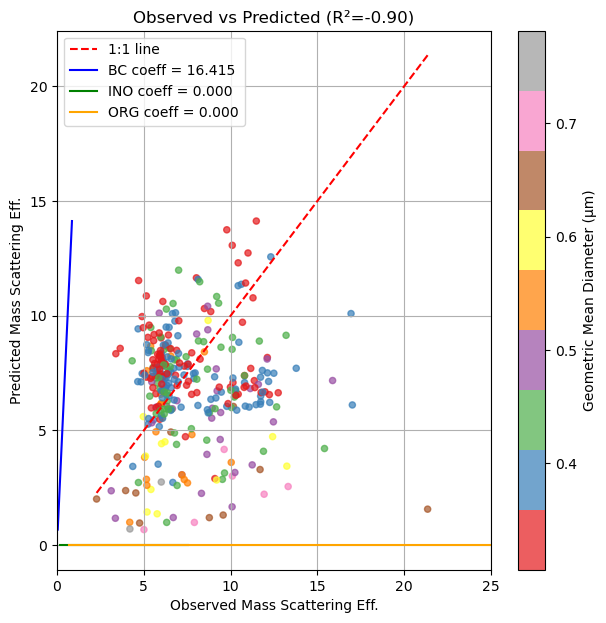

In [74]:
# --- Observed vs Predicted with DG colorbar + coefficient lines ---
plt.figure(figsize=(7,7))
sc = plt.scatter(y, y_pred, c=DG, cmap="Set1", alpha=0.7, s=20)

# 1:1 line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label="1:1 line")

# Contribution lines (individual predictors with NNLS coefficients)
colors = {"BC": "blue", "INO": "green", "ORG": "orange"}
for param, c in zip(X.columns, coef):
    # Make a line using observed predictor values scaled by coefficient
    x_line = np.linspace(X[param].min(), X[param].max(), 100)
    y_line = c * x_line
    plt.plot(x_line, y_line, label=f"{param} coeff = {c:.3f}", color=colors[param])

plt.xlabel("Observed Mass Scattering Eff.")
plt.xlim(0,25)
plt.ylabel("Predicted Mass Scattering Eff.")
plt.title(f"Observed vs Predicted (R²={r_squared:.2f})")
plt.colorbar(sc, label="Geometric Mean Diameter (µm)")
plt.legend()
plt.grid(True)
plt.show()

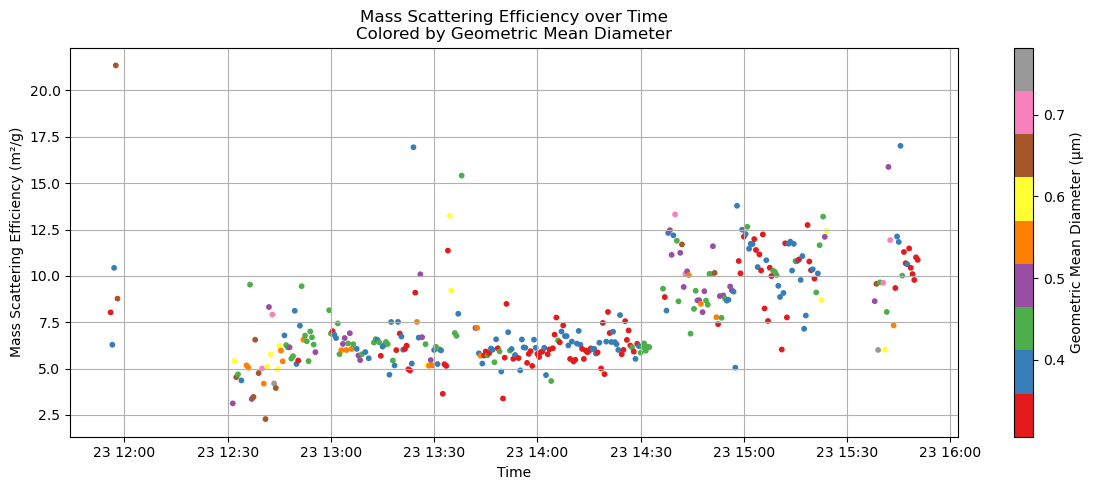

In [75]:
combined_data = []
for entry in results_sct:
    try:
        df = pd.DataFrame({
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
            'ME': entry['Mass scattering eff (growth correction)'],
            'DG': entry['DG_aligned'],
            'Flight': entry['flight']
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)
plt.figure(figsize=(12,5))

# Scatter time series with DG color
sc = plt.scatter(df_all.index, df_all["ME"], 
                 c=df_all["DG"], cmap="Set1", s=10)

plt.xlabel("Time")
plt.ylabel("Mass Scattering Efficiency (m²/g)")
plt.title("Mass Scattering Efficiency over Time\nColored by Geometric Mean Diameter")
plt.colorbar(sc, label="Geometric Mean Diameter (µm)")
plt.grid(True)
plt.tight_layout()
plt.show()

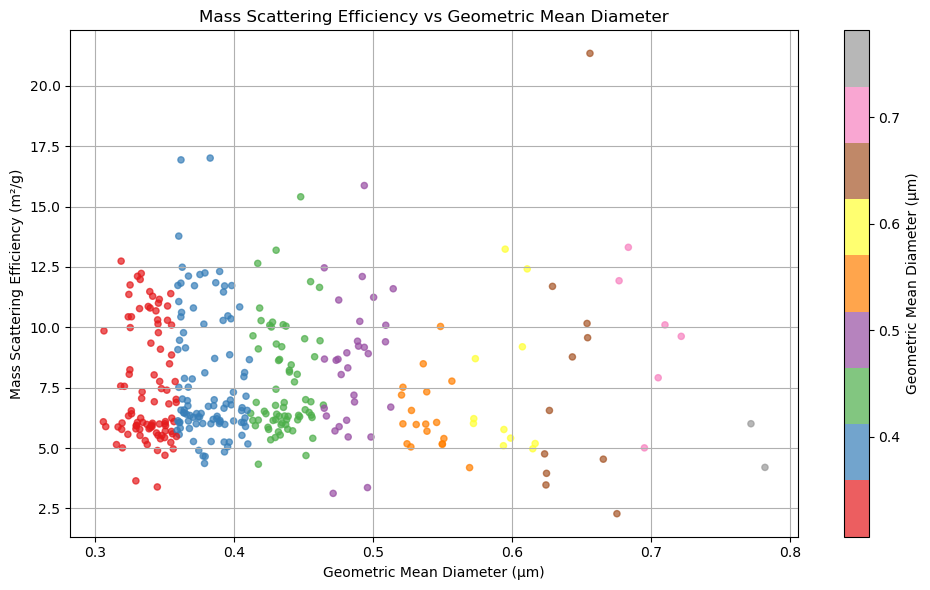

In [92]:
# Combine all flight data
combined_data = []
for entry in results_sct:
    try:
        df = pd.DataFrame({
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
            'ME': entry['Mass scattering eff (growth correction)'],
            'DG': entry['DG_aligned'],
            'CO': entry['CO'],
            'Flight': entry['flight']
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)

plt.figure(figsize=(10,6))

# Scatter plot ME vs DG
sc = plt.scatter(df_all["DG"], df_all["ME"], 
                 c=df_all["DG"], cmap="Set1", s=20, alpha=0.7)

plt.xlabel("Geometric Mean Diameter (µm)")
plt.ylabel("Mass Scattering Efficiency (m²/g)")
plt.title("Mass Scattering Efficiency vs Geometric Mean Diameter")
plt.colorbar(sc, label="Geometric Mean Diameter (µm)")
plt.grid(True)
plt.tight_layout()
plt.show()

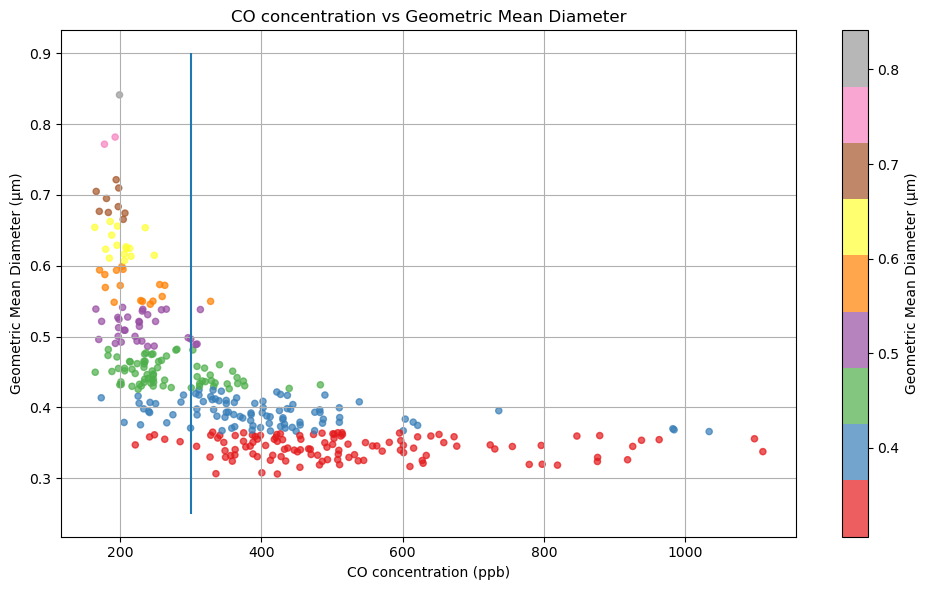

In [99]:
# Combine all flight data
combined_data = []
for entry in results_sct:
    try:
        df = pd.DataFrame({
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
            'ME': entry['Mass scattering eff (growth correction)'],
            'DG': entry['DG_aligned'],
            'CO': entry['CO'],
            'Flight': entry['flight']
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)

plt.figure(figsize=(10,6))

# Scatter plot ME vs DG
sc = plt.scatter(df_all["CO"], df_all["DG"], 
                 c=df_all["DG"], cmap="Set1", s=20, alpha=0.7)
plt.vlines(300,0.25,0.9)
plt.ylabel("Geometric Mean Diameter (µm)")
plt.xlabel("CO concentration (ppb)")
plt.title("CO concentration vs Geometric Mean Diameter")
plt.colorbar(sc, label="Geometric Mean Diameter (µm)")
plt.grid(True)
plt.tight_layout()
plt.show()

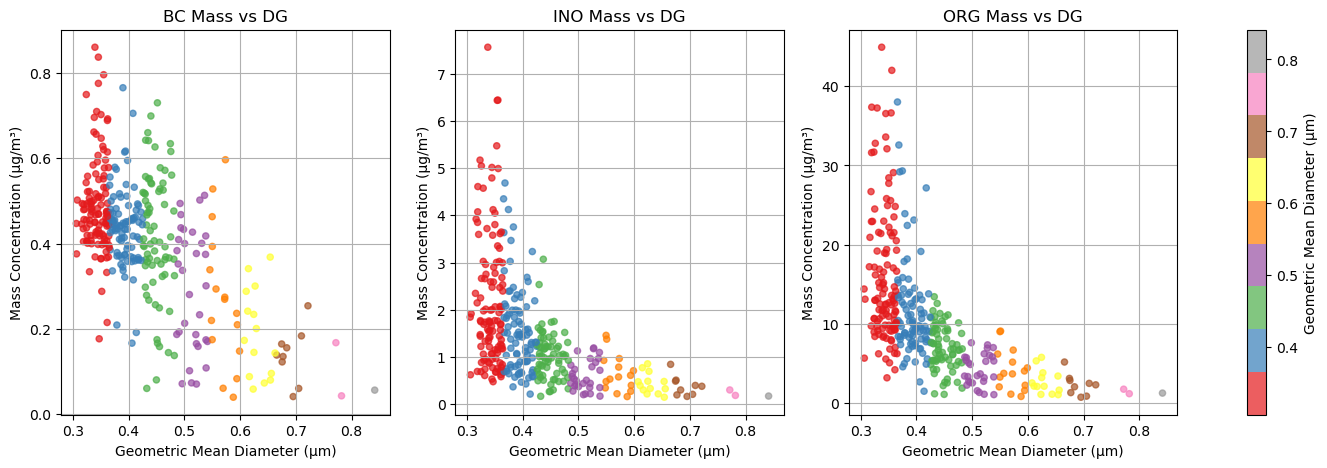

In [50]:
# Combine all flight data
combined_data = []
for entry in results_sct:
    try:
        df = pd.DataFrame({
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
            'ME': entry['Mass scattering eff (growth correction)'],
            'DG': entry['DG_aligned'],
            'Flight': entry['flight']
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)

species_data = ['BC', 'INO', 'ORG']
colors = ['black', 'red', 'green']

fig, axes = plt.subplots(1, 3, figsize=(18,5))  # No shared y-axis

for ax, species, color in zip(axes, species_data, colors):
    sc = ax.scatter(df_all['DG'], df_all[species], 
                    c=df_all['DG'], cmap='Set1', s=20, alpha=0.7)
    ax.set_xlabel("Geometric Mean Diameter (µm)")
    ax.set_title(f"{species} Mass vs DG")
    ax.grid(True)
    ax.set_ylabel("Mass Concentration (µg/m³)")

# Single colorbar for all subplots
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), label="Geometric Mean Diameter (µm)")
#plt.tight_layout()
plt.show()

/tmp/ipykernel_380/3089538519.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_all.groupby('DG_bin')[species].mean()


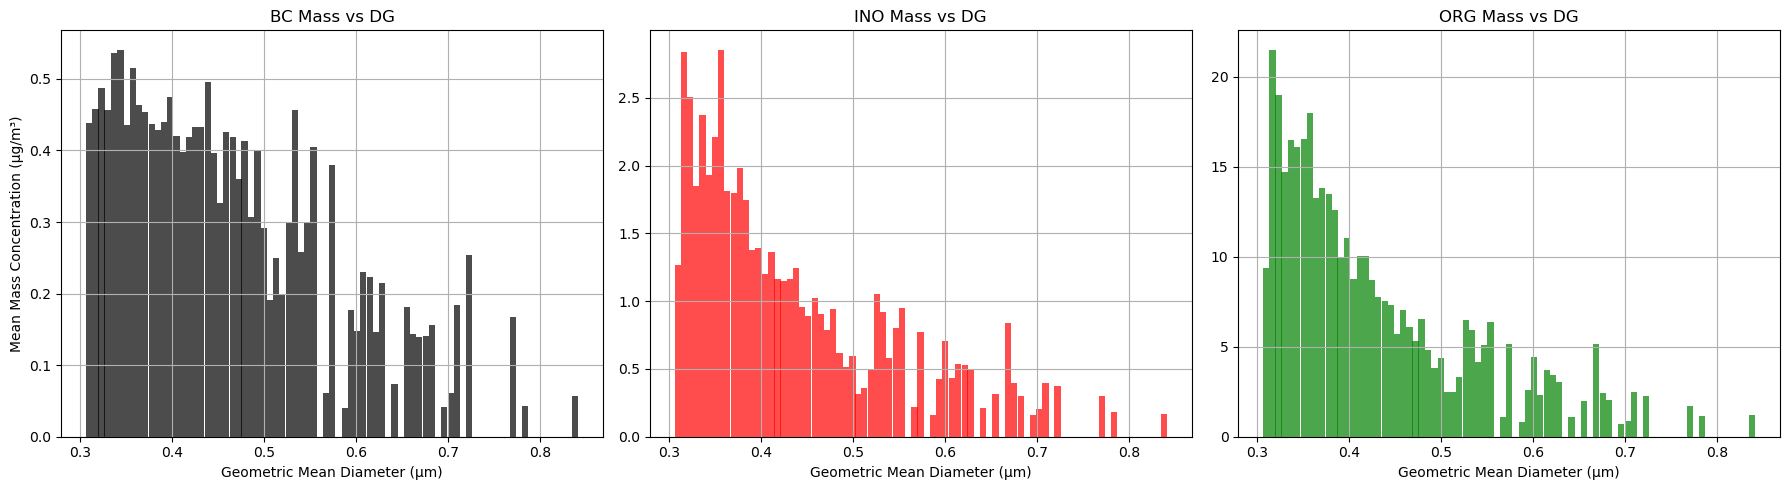

In [51]:
# --- Combine all flight data ---
combined_data = []
for entry in results_sct:
    try:
        df = pd.DataFrame({
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
            'ME': entry['Mass scattering eff (growth correction)'],
            'DG': entry['DG_aligned'],
            'Flight': entry['flight']
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

df_all = pd.concat(combined_data)

# --- Bin DG values ---
bins = np.linspace(df_all['DG'].min(), df_all['DG'].max(), 80)  # 30 bins
df_all['DG_bin'] = pd.cut(df_all['DG'], bins)

species_data = ['BC', 'INO', 'ORG']
colors = ['black', 'red', 'green']

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, species, color in zip(axes, species_data, colors):
    # Compute mean mass per DG bin
    grouped = df_all.groupby('DG_bin')[species].mean()
    centers = [interval.mid for interval in grouped.index]

    ax.bar(centers, grouped.values, width=np.diff(bins).mean(), color=color, alpha=0.7)
    ax.set_xlabel("Geometric Mean Diameter (µm)")
    ax.set_title(f"{species} Mass vs DG")
    ax.grid(True)

axes[0].set_ylabel("Mean Mass Concentration (µg/m³)")

plt.tight_layout()
plt.show()


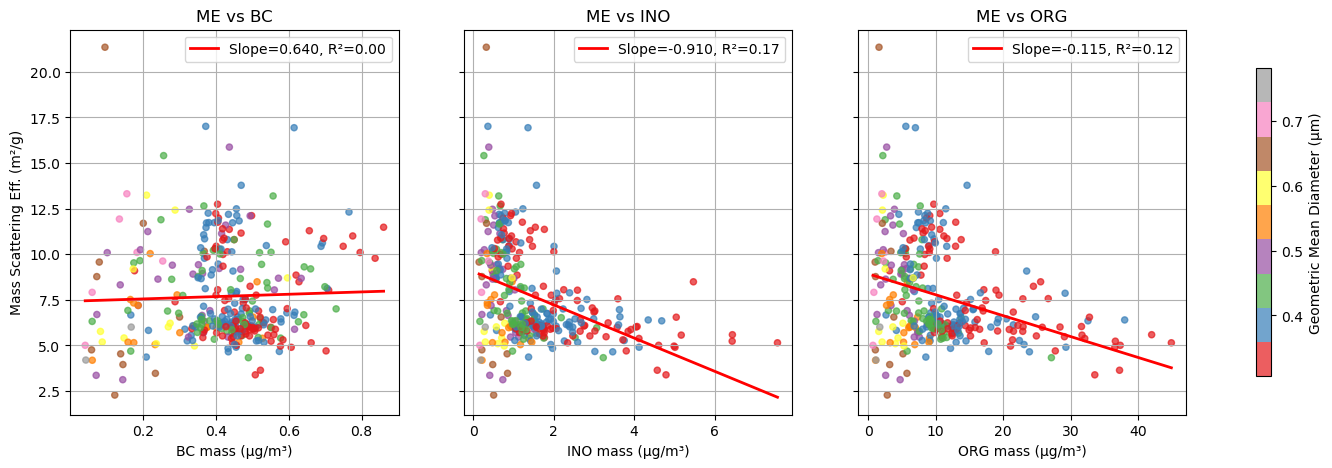

In [52]:
#from sklearn.linear_model import LinearRegression

# Combine all flight data into a single dataframe
combined_data = []
for entry in results_sct:
    try:
        df = pd.DataFrame({
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
            'ME': entry['Mass scattering eff (growth correction)'],
            'DG': entry['DG_aligned'],
            'Flight': entry['flight']
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)

# Drop rows with NaNs
df_all = df_all.dropna(subset=['BC', 'INO', 'ORG', 'ME', 'DG'])

# Predictor variables list
predictors = ['BC', 'INO', 'ORG']

# --- Plot setup ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, var in zip(axes, predictors):
    X = df_all[[var]].values.reshape(-1, 1)
    y = df_all['ME'].values
    DG = df_all['DG'].values

    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)
    slope = model.coef_[0]
    intercept = model.intercept_
    r2 = model.score(X, y)

    # Scatter plot with DG color
    sc = ax.scatter(X, y, c=DG, cmap="Set1", alpha=0.7, s=20)

    # Regression line
    x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_line = model.predict(x_line)
    ax.plot(x_line, y_line, 'r-', lw=2, label=f"Slope={slope:.3f}, R²={r2:.2f}")

    #ax.set_xscale("log")
    #ax.set_yscale("log")
    ax.set_xlabel(f"{var} mass (µg/m³)")
    ax.set_title(f"ME vs {var}")
    ax.legend()
    ax.grid(True)

# Shared Y label
axes[0].set_ylabel("Mass Scattering Eff. (m²/g)")

# Colorbar for DG
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("Geometric Mean Diameter (µm)")

#plt.tight_layout()
plt.show()


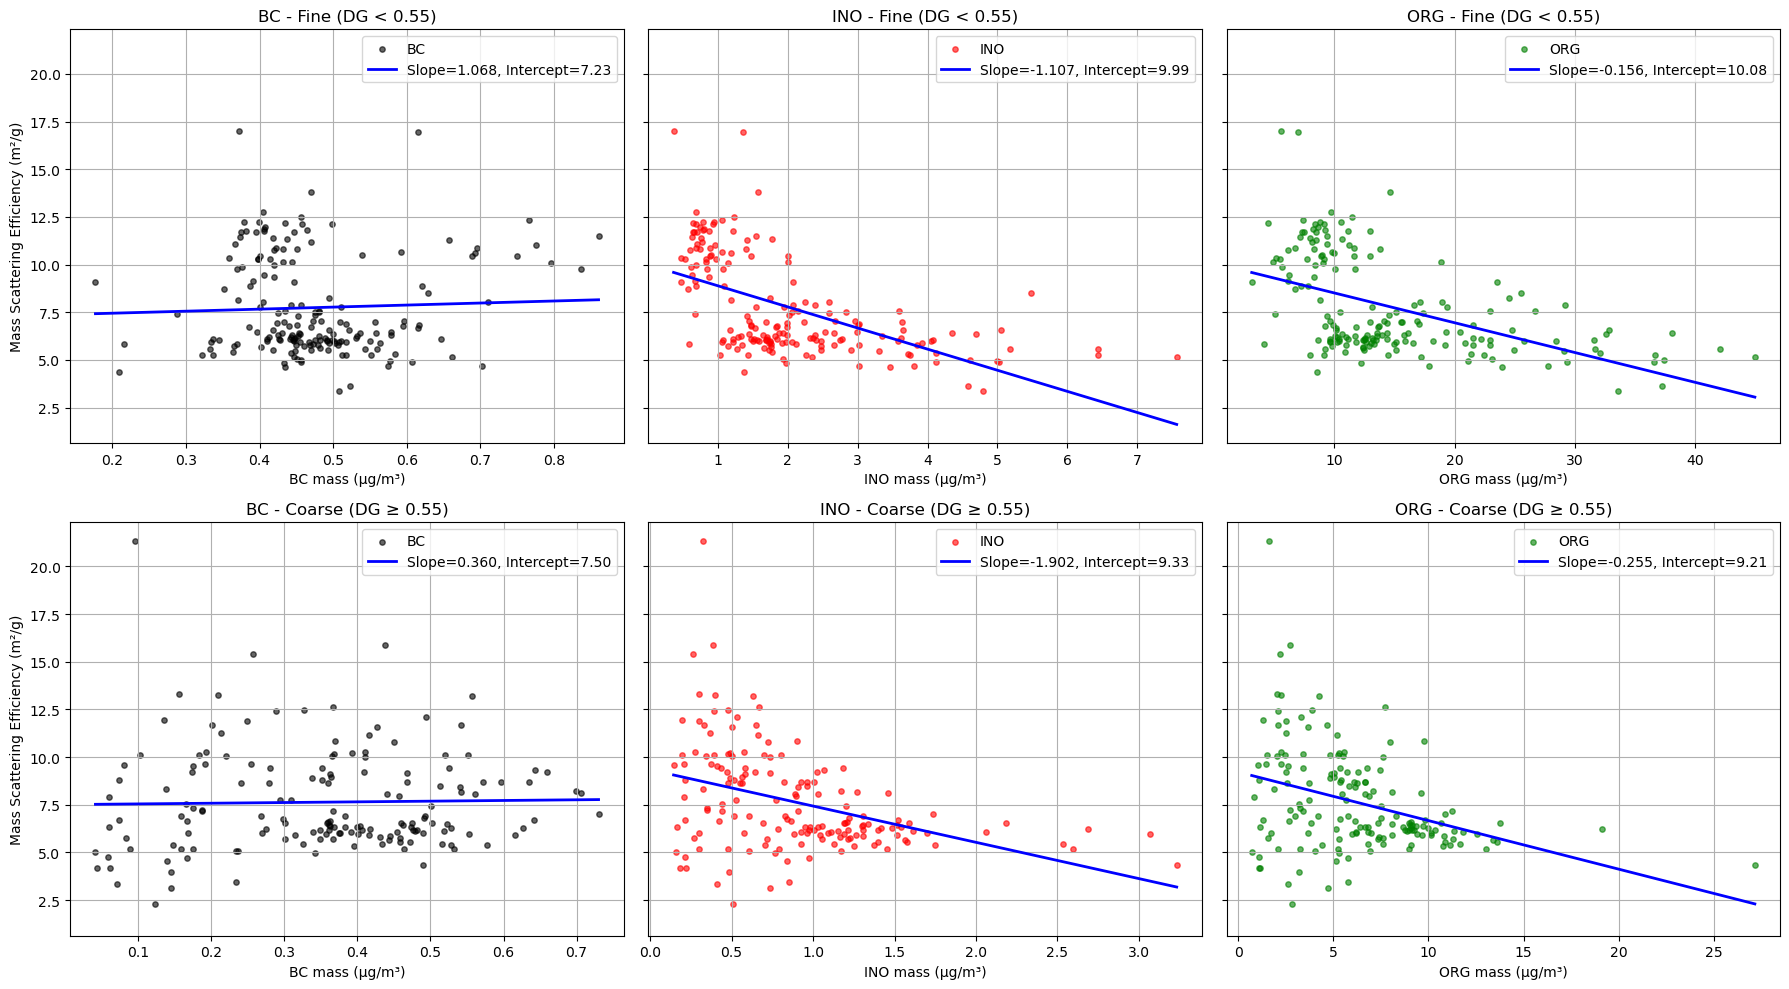

In [53]:
# --- Combine all flight data ---
combined_data = []
for entry in results_sct:
    try:
        df = pd.DataFrame({
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
            'ME': entry['Mass scattering eff (growth correction)'],
            'DG': entry['DG_aligned'],
            'Flight': entry['flight']
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

df_all = pd.concat(combined_data)
df_all = df_all.dropna(subset=['BC', 'INO', 'ORG', 'ME', 'DG'])

# --- Split into fine and coarse regimes ---
df_fine = df_all[df_all['DG'] < 0.40]
df_coarse = df_all[df_all['DG'] >= 0.40]

species_data = ['BC', 'INO', 'ORG']
colors = ['black', 'red', 'green']

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

for col, species, color in zip(range(3), species_data, colors):
    for row, (subset, regime) in enumerate([(df_fine, "Fine (DG < 0.55)"), 
                                            (df_coarse, "Coarse (DG ≥ 0.55)")]):
        
        ax = axes[row, col]
        X = subset[[species]].values.reshape(-1, 1)
        y = subset['ME'].values
        
        # Scatter plot
        ax.scatter(X, y, alpha=0.6, color=color, s=15, label=f"{species}")
        
        # --- Linear regression ---
        if len(X) > 1:
            model = LinearRegression()
            model.fit(X, y)
            slope = model.coef_[0]
            intercept = model.intercept_
            
            # Line for plotting
            x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
            y_line = model.predict(x_line)
            ax.plot(x_line, y_line, 'b-', lw=2, 
                    label=f"Slope={slope:.3f}, Intercept={intercept:.2f}")
        
        ax.set_xlabel(f"{species} mass (µg/m³)")
        if col == 0:
            ax.set_ylabel("Mass Scattering Efficiency (m²/g)")
        ax.set_title(f"{species} - {regime}")
        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.show()

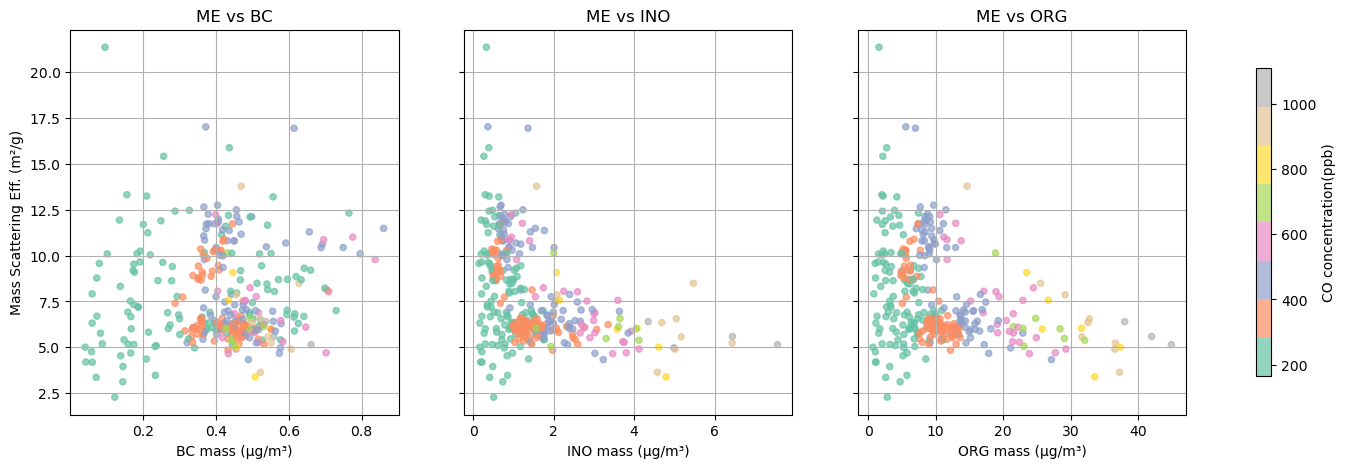

In [102]:
# Combine all flight data into a single dataframe
combined_data = []
for entry in results_sct:
    try:
        df = pd.DataFrame({
            'BC': entry['BC'],
            'INO': entry['INO'],
            'ORG': entry['ORG'],
            'ME': entry['Mass scattering eff (growth correction)'],
            'DG': entry['DG_aligned'],
            'CO': entry['CO'],
            'Flight': entry['flight']
        })
        combined_data.append(df)
    except Exception as e:
        print(f"Skipping flight {entry['flight']} due to error: {e}")

# Concatenate all flights
df_all = pd.concat(combined_data)

# Drop rows with NaNs
df_all = df_all.dropna(subset=['BC', 'INO', 'ORG', 'ME', 'DG','CO'])

# Predictor variables list
predictors = ['BC', 'INO', 'ORG']

# --- Plot setup ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, var in zip(axes, predictors):
    X = df_all[var].values
    y = df_all['ME'].values
    DG = df_all['DG'].values
    CO = df_all['CO'].values

    # Scatter plot with DG color
    sc = ax.scatter(X, y, c=CO, cmap="Set2", alpha=0.7, s=20)

    ax.set_xlabel(f"{var} mass (µg/m³)")
    ax.set_title(f"ME vs {var}")
    ax.grid(True)

# Shared Y label
axes[0].set_ylabel("Mass Scattering Eff. (m²/g)")

# Colorbar for DG
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("CO concentration(ppb)")

#plt.tight_layout()
plt.show()

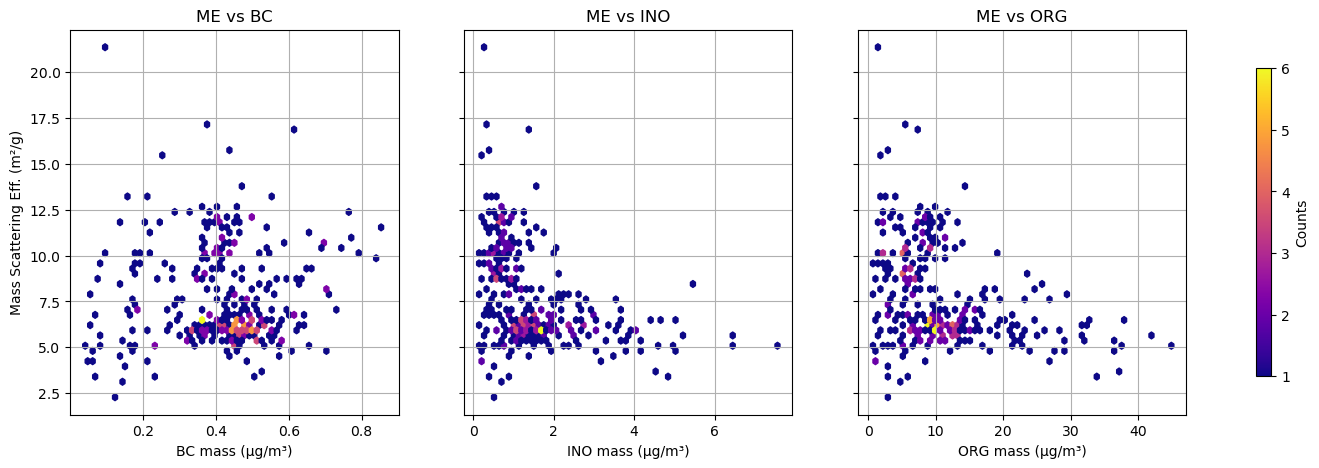

In [55]:
# --- Using hexbin instead ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, var in zip(axes, predictors):
    x = df_all[var].values
    y = df_all['ME'].values

    hb = ax.hexbin(x, y, gridsize=60, cmap="plasma", mincnt=1)

    ax.set_xlabel(f"{var} mass (µg/m³)")
    ax.set_title(f"ME vs {var}")
    ax.grid(True)

axes[0].set_ylabel("Mass Scattering Eff. (m²/g)")

cbar = fig.colorbar(hb, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("Counts")

#plt.tight_layout()
plt.show()

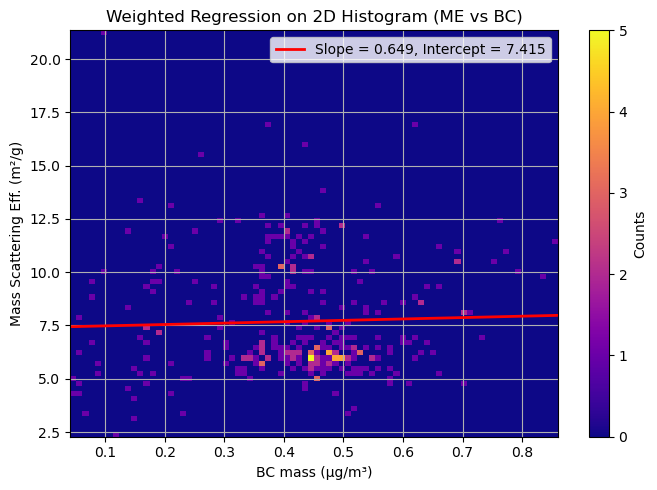

In [56]:
# Data
x = df_all['BC'].values          # predictor (mass concentration)
y = df_all['ME'].values          # response (mass scattering eff)

# --- 2D histogram (counts on linear scale) ---
xbins = 80
ybins = 80
H, xedges, yedges = np.histogram2d(x, y, bins=[xbins, ybins])

# Plot the histogram correctly oriented
fig, ax = plt.subplots(figsize=(7,5))
pcm = ax.pcolormesh(xedges, yedges, H.T, cmap='plasma', shading='auto')
cbar = fig.colorbar(pcm, ax=ax, label='Counts')  # linear counts

# --- Build weighted regression data from bin centers ---
x_centers = 0.5 * (xedges[:-1] + xedges[1:])     # len = xbins
y_centers = 0.5 * (yedges[:-1] + yedges[1:])     # len = ybins
XX, YY = np.meshgrid(x_centers, y_centers, indexing='ij')  # shapes (xbins, ybins)

counts = H                                     # same shape (xbins, ybins)
mask = counts > 0                              # use populated bins only

xw = XX[mask].reshape(-1, 1)                   # weighted X (bin centers)
yw = YY[mask]                                  # weighted Y (bin centers)
w  = counts[mask]                              # weights = counts

# --- Weighted linear regression ---
model = LinearRegression()
model.fit(xw, yw, sample_weight=w)

slope = float(model.coef_[0])
intercept = float(model.intercept_)

# Regression line over the raw x-range
x_line = np.linspace(np.nanmin(x), np.nanmax(x), 200)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r-', lw=2,
        label=f"Slope = {slope:.3f}, Intercept = {intercept:.3f}")

# Labels & style
ax.set_xlabel("BC mass (µg/m³)")
ax.set_ylabel("Mass Scattering Eff. (m²/g)")
ax.set_title("Weighted Regression on 2D Histogram (ME vs BC)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

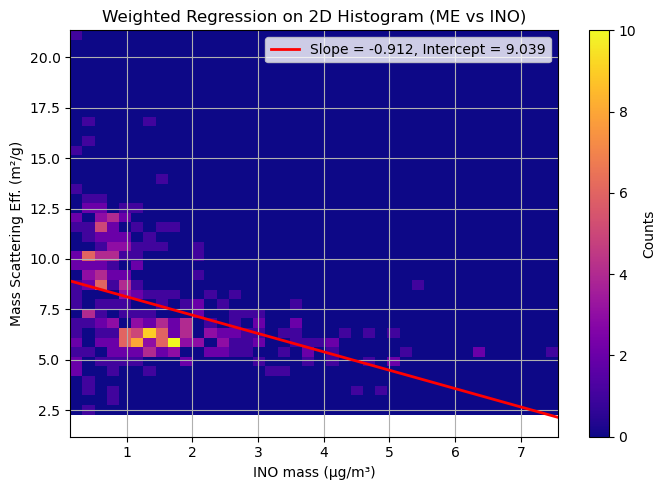

In [57]:
# Data
x = df_all['INO'].values          # predictor (mass concentration)
y = df_all['ME'].values          # response (mass scattering eff)

# --- 2D histogram (counts on linear scale) ---
xbins = 40
ybins = 40
H, xedges, yedges = np.histogram2d(x, y, bins=[xbins, ybins])

# Plot the histogram correctly oriented
fig, ax = plt.subplots(figsize=(7,5))
pcm = ax.pcolormesh(xedges, yedges, H.T, cmap='plasma', shading='auto')
cbar = fig.colorbar(pcm, ax=ax, label='Counts')  # linear counts

# --- Build weighted regression data from bin centers ---
x_centers = 0.5 * (xedges[:-1] + xedges[1:])     # len = xbins
y_centers = 0.5 * (yedges[:-1] + yedges[1:])     # len = ybins
XX, YY = np.meshgrid(x_centers, y_centers, indexing='ij')  # shapes (xbins, ybins)

counts = H                                     # same shape (xbins, ybins)
mask = counts > 0                              # use populated bins only

xw = XX[mask].reshape(-1, 1)                   # weighted X (bin centers)
yw = YY[mask]                                  # weighted Y (bin centers)
w  = counts[mask]                              # weights = counts

# --- Weighted linear regression ---
model = LinearRegression()
model.fit(xw, yw, sample_weight=w)

slope = float(model.coef_[0])
intercept = float(model.intercept_)

# Regression line over the raw x-range
x_line = np.linspace(np.nanmin(x), np.nanmax(x), 200)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r-', lw=2,
        label=f"Slope = {slope:.3f}, Intercept = {intercept:.3f}")

# Labels & style
ax.set_xlabel("INO mass (µg/m³)")
ax.set_ylabel("Mass Scattering Eff. (m²/g)")
ax.set_title("Weighted Regression on 2D Histogram (ME vs INO)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

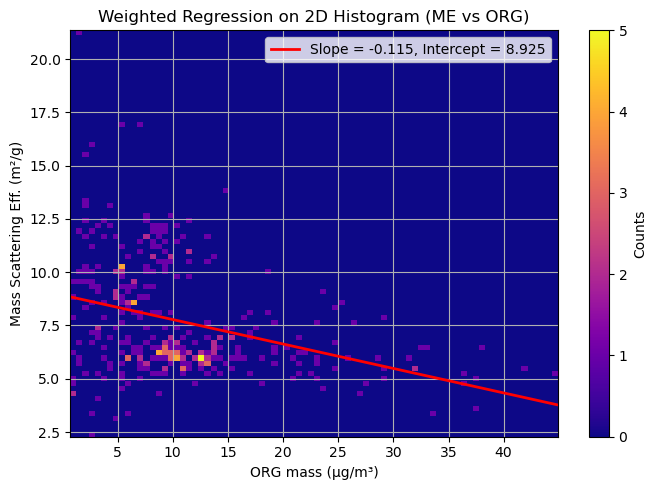

In [58]:
# Data
x = df_all['ORG'].values          # predictor (mass concentration)
y = df_all['ME'].values          # response (mass scattering eff)

# --- 2D histogram (counts on linear scale) ---
xbins = 80
ybins = 80
H, xedges, yedges = np.histogram2d(x, y, bins=[xbins, ybins])

# Plot the histogram correctly oriented
fig, ax = plt.subplots(figsize=(7,5))
pcm = ax.pcolormesh(xedges, yedges, H.T, cmap='plasma', shading='auto')
cbar = fig.colorbar(pcm, ax=ax, label='Counts')  # linear counts

# --- Build weighted regression data from bin centers ---
x_centers = 0.5 * (xedges[:-1] + xedges[1:])     # len = xbins
y_centers = 0.5 * (yedges[:-1] + yedges[1:])     # len = ybins
XX, YY = np.meshgrid(x_centers, y_centers, indexing='ij')  # shapes (xbins, ybins)

counts = H                                     # same shape (xbins, ybins)
mask = counts > 0                              # use populated bins only

xw = XX[mask].reshape(-1, 1)                   # weighted X (bin centers)
yw = YY[mask]                                  # weighted Y (bin centers)
w  = counts[mask]                              # weights = counts

# --- Weighted linear regression ---
model = LinearRegression()
model.fit(xw, yw, sample_weight=w)

slope = float(model.coef_[0])
intercept = float(model.intercept_)

# Regression line over the raw x-range
x_line = np.linspace(np.nanmin(x), np.nanmax(x), 200)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r-', lw=2,
        label=f"Slope = {slope:.3f}, Intercept = {intercept:.3f}")

# Labels & style
ax.set_xlabel("ORG mass (µg/m³)")
ax.set_ylabel("Mass Scattering Eff. (m²/g)")
ax.set_title("Weighted Regression on 2D Histogram (ME vs ORG)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()